# Analysis of wavefront sensor data from ALS 5.3.1

Date: Created May 2026 

Author: Wei "Francis" He (francisho@lbl.gov / whorwhey@gmail.com)

Based on earlier versions by Dr. Antoine Islegen-Wojdyla and myself. 

___

## Overview

In this notebook, we test the usage of `wfs_online` script. The goal is to conveniently use it to analyze the wavefront lively at the beamline. 

Since `tiled` is not responding, we'd use the local dataset for now. 


# SETUP 

## Import library 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from tiled.client import from_uri
import os


## Access Data from the Server

__Note:__ We tried read data from db with `tiled.__version__='0.2.9'`, but it failed; had to reinstall a 0.2.1 version to make it work. 

In [ ]:
# --- Server connection ---
api_key_path = "/Users/francisho/Documents/TILED_SINGLE_USER_API_KEY.txt"   # Change this path to where your API key is stored 

with open(api_key_path, "r") as f:
    api_key = f.read().strip()

if not api_key:
    raise ValueError("API key file is empty or not found.")

tiled_client = from_uri("http://131.243.80.226:8000", api_key=api_key)

__Important scans files:__

`Uid = '88dd6a7f-0338-446f-8185-fa9e004add04'`: A grid scan for `RE(grid_scan([basler_5472], mono_energy, 7000, 10000, 7, Obender, -2000, -0000, 11, snake_axes=False, md=md))`


In [ ]:
# --- Dataset ---
DATASET_ID = '88dd6a7f-0338-446f-8185-fa9e004add04'
db = tiled_client[DATASET_ID]

# Metadata

wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
exp_time_s = db.metadata['start']['exposure time [s]']
pixel_size_um = db.metadata['start']['pixel size [um]']
binning = db.metadata['start']['binning']
effective_pixel_size_um = db.metadata['start']['effective pixel size [um]']
camera_model = db.metadata['start']['camera model']
objective_model = db.metadata['start']['objective model']

print(f"Camera:          {camera_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm  (binning: {binning}×)")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")
print(f"WFS chip position (mm): {wfs_chip_pos_mm}")


In [ ]:
# Arrays (slow, ~20 seconds to load) 
images    = db['primary']['basler_5472_image'].read()
energy_eV = db['primary']['mono_energy_energy_eV'].read()
bender_um = db['primary']['bender_um'].read()

print(f"Images shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")

In [ ]:
# Physical Parameters (Experimental Setup)

camera_pixel_m = 3.45e-6      # Camera pixel size [m]
magnification = 2.85          # Objective magnification (Boli optics)
dx_m = camera_pixel_m / magnification  # Effective pixel size [m]

energy_eV = 607               # Photon energy [eV]
wavelength_m = 1.23984e-6 / energy_eV

# Grating
grating_pitch_m = 22e-6      # Shearing grating pitch [m]

In [ ]:
# Physical Parameters (Experimental Setup)

camera_pixel_m = 3.45e-6      # Camera pixel size [m]
magnification = 2.85          # Objective magnification (Boli optics)
dx_m = camera_pixel_m / magnification  # Effective pixel size [m]

energy_eV = 607               # Photon energy [eV]
wavelength_m = 1.23984e-6 / energy_eV

# Grating
grating_pitch_m = 22e-6      # Shearing grating pitch [m]

## Access Data from Local Files


Loaded: WFS210515-0002-025.tif
Image dimensions: 4112 × 3008 pixels


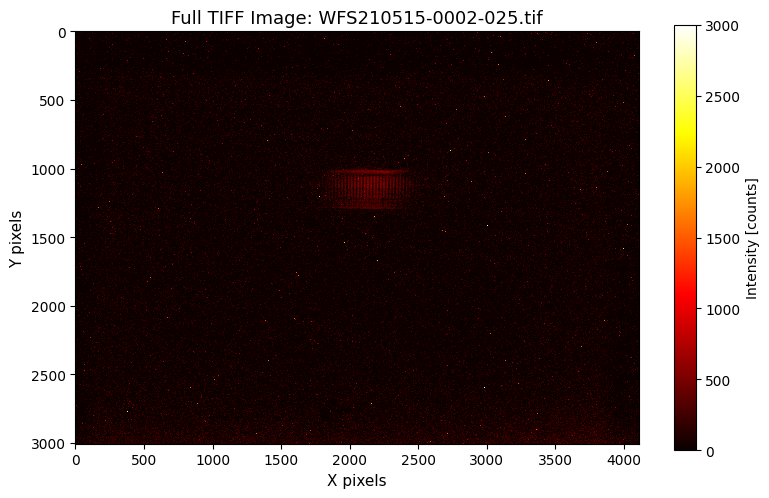

In [2]:
from PIL import Image

# Load TIFF Image
filename = "WFS210515-0002-025.tif"
im = Image.open(f'{filename}')
width, height = im.size

print(f"Loaded: {filename}")
print(f"Image dimensions: {width} × {height} pixels")

# Visualize full image
plt.figure(figsize=(8, 5))
plt.imshow(np.array(im), cmap='hot', interpolation='nearest', vmax=3000)
plt.title(f'Full TIFF Image: {filename}', fontsize=13)
plt.xlabel('X pixels', fontsize=11)
plt.ylabel('Y pixels', fontsize=11)
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

In [3]:
# Physical Parameters (Experimental Setup)

camera_pixel_m = 3.45e-6      # Camera pixel size [m]
magnification = 2.85          # Objective magnification (Boli optics)
dx_m = camera_pixel_m / magnification  # Effective pixel size [m]

energy_eV = 607               # Photon energy [eV]
wavelength_m = 1.23984e-6 / energy_eV

# Grating
grating_pitch_m = 22e-6      # Shearing grating pitch [m]

# COMPOSING

## Components


In [28]:
def extract_profile(image_2d, roi, axis=1):
    """Average a 2-D detector image to a 1-D fringe profile.

    Parameters
    ----------
    image_2d : ndarray, shape (n0, n1)
        Raw detector image.
    roi : slice
        Slice along the averaging axis (the no-fringe direction).
        E.g. slice(470, 486) keeps rows 470–485 if axis=1, or columns
        470–485 if axis=0.
    axis : int, optional (default 1)
        Axis to average over. The fringe direction is `1 - axis`.
        - axis=1 → average over columns, profile runs along rows.
        - axis=0 → average over rows,    profile runs along columns.

    Returns
    -------
    profile : ndarray, shape (n_{1-axis},)
        1-D intensity profile along the fringe direction.
    """
    # Build a 2-tuple of slices: full on the fringe axis, roi on the avg axis.
    slicer = [slice(None), slice(None)]
    slicer[axis] = roi
    sub = image_2d[tuple(slicer)]
    return np.mean(sub, axis=axis).astype(float)


In [29]:
im_arr = np.array(im, dtype=float)
print(f"Image shape (rows, cols): {im_arr.shape}")

y_roi_old = slice(1090, 1190)   # row band over the beam — tune after looking
axis_old  = 0                   # average over rows
profile   = extract_profile(im_arr, y_roi_old, axis=axis_old)

print(f"profile shape: {profile.shape}  (expect ({im_arr.shape[1]},))")
print(f"profile range: [{profile.min():.1f}, {profile.max():.1f}]")

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Top: image with ROI overlaid
ax = axes[0]
ax.imshow(im_arr, cmap='hot', vmax=3000, aspect='auto')
ax.axhspan(y_roi_old.start, y_roi_old.stop, color='cyan', alpha=0.3, label=f'roi {y_roi_old}')
ax.set_title('Image with row-band ROI')
ax.set_xlabel('X pixels (fringe direction)')
ax.set_ylabel('Y pixels (averaging direction)')
ax.legend(loc='upper right', fontsize=9)

# Bottom: 1-D profile
ax = axes[1]
x_mm = np.arange(len(profile)) * dx_m * 1e3
ax.plot(x_mm, profile, lw=0.8)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Intensity [counts]')
ax.set_title(f'extract_profile — axis={axis_old}, roi={y_roi_old}')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Zoom in on the beam region for fringe visibility
beam_xmin_px = 1500
beam_xmax_px = 3000
fig, ax = plt.subplots(figsize=(12, 4))
xz_mm = np.arange(beam_xmin_px, beam_xmax_px) * dx_m * 1e3
ax.plot(xz_mm, profile[beam_xmin_px:beam_xmax_px], lw=0.8)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Intensity [counts]')
ax.set_title(f'Zoom on beam region (cols {beam_xmin_px}–{beam_xmax_px})')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

TypeError: float() argument must be a string or a real number, not 'AxesImage'

In [30]:
def find_carrier(profile, dx, grating_pitch, band_factor=1.5):
    """Locate the carrier peak in the FFT of a fringe profile.

    The carrier is the +1-order spatial frequency of the shearing grating,
    nominally at f = 1/p. The actual peak shifts slightly with wavefront
    tilt, so we search a band around 1/p rather than picking it as known.

    Parameters
    ----------
    profile : array_like, shape (N,)
        1-D fringe intensity profile from extract_profile.
    dx : float  [m]
        Pixel pitch in the fringe direction.
    grating_pitch : float  [m]
        Nominal grating pitch (fabrication spec).
    band_factor : float, optional (default 1.5)
        Search band is (1/p / band_factor,  band_factor / p).
        Set higher (e.g. 1.5) if strong tilt pulls the peak far from 1/p.

    Returns
    -------
    out : dict
        k_peak     [cyc/m]  measured carrier frequency
        k_amp      [a.u.]   |FFT| at the carrier — quality indicator
        k_ideal    [cyc/m]  1/grating_pitch
        fft_avg    ndarray  centered FFT of the profile (complex)
        freq       ndarray  centered frequency axis [cyc/m]
        band       (lo, hi) the search band actually used [cyc/m]
    """
    profile = np.asarray(profile, dtype=float).ravel()
    N = len(profile)

    fft_avg = np.fft.fftshift(np.fft.fft(profile))
    freq    = np.fft.fftshift(np.fft.fftfreq(N, dx))

    k_ideal = 1.0 / grating_pitch
    band_lo = k_ideal / band_factor
    band_hi = k_ideal * band_factor

    search_mask = (freq >= band_lo) & (freq <= band_hi)
    if not search_mask.any():
        raise ValueError(
            f"No FFT frequencies fall inside search band "
            f"[{band_lo*1e-3:.1f}, {band_hi*1e-3:.1f}] cyc/mm. "
            f"Check dx, grating_pitch, and N."
        )

    carrier_idx = np.argmax(np.abs(fft_avg) * search_mask)
    k_peak      = freq[carrier_idx]
    k_amp       = float(np.abs(fft_avg[carrier_idx]))

    return dict(
        k_peak  = k_peak,
        k_amp   = k_amp,
        k_ideal = k_ideal,
        fft_avg = fft_avg,
        freq    = freq,
        band    = (band_lo, band_hi),
    )


Ideal carrier (1/p) : 45.45 cyc/mm
Search band         : [30.30, 68.18] cyc/mm
Measured k_peak     : 35.16 cyc/mm
Ratio k_peak/k_ideal: 0.7735
k_amp (peak |FFT|)  : 51023.4


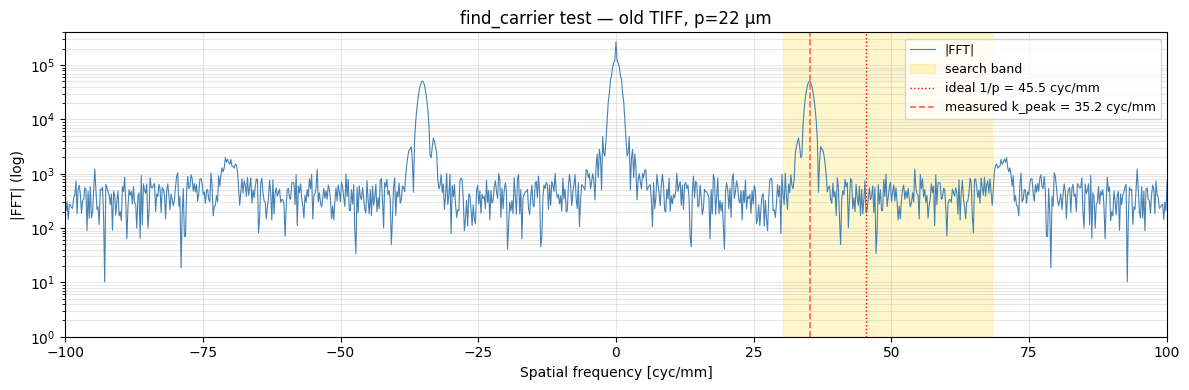

In [31]:
# Test find_carrier
carrier = find_carrier(profile, dx_m, grating_pitch_m, band_factor=1.5)

print(f"Ideal carrier (1/p) : {carrier['k_ideal']*1e-3:.2f} cyc/mm")
print(f"Search band         : [{carrier['band'][0]*1e-3:.2f}, "
      f"{carrier['band'][1]*1e-3:.2f}] cyc/mm")
print(f"Measured k_peak     : {carrier['k_peak']*1e-3:.2f} cyc/mm")
print(f"Ratio k_peak/k_ideal: {carrier['k_peak']/carrier['k_ideal']:.4f}")
print(f"k_amp (peak |FFT|)  : {carrier['k_amp']:.1f}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 4))
freq    = carrier['freq']
fft_avg = carrier['fft_avg']

ax.semilogy(freq * 1e-3, np.abs(fft_avg), lw=0.8, color='steelblue', label='|FFT|')
ax.axvspan(carrier['band'][0]*1e-3, carrier['band'][1]*1e-3,
           color='gold', alpha=0.2, label='search band')
ax.axvline(carrier['k_ideal']*1e-3, color='red', ls=':', lw=1,
           label=f'ideal 1/p = {carrier["k_ideal"]*1e-3:.1f} cyc/mm')
ax.axvline(carrier['k_peak']*1e-3, color='tomato', ls='--', lw=1.2,
           label=f'measured k_peak = {carrier["k_peak"]*1e-3:.1f} cyc/mm')

ax.set_xlabel('Spatial frequency [cyc/mm]')
ax.set_ylabel('|FFT| (log)')
ax.set_title(f'find_carrier test — old TIFF, p={grating_pitch_m*1e6:.0f} µm')
ax.set_xlim(-100, 100)
ax.set_ylim(1e0, np.abs(fft_avg).max() * 1.5)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
def extract_envelopes(fft_avg, freq, k_peak,
                      sigma_ratio_0=5, sigma_ratio_1=10):
    """Extract 0th-order and +1-order complex envelopes by Gaussian filtering.

    Parameters
    ----------
    fft_avg : ndarray, shape (N,) complex
        Centered FFT of the fringe profile (from find_carrier).
    freq : ndarray, shape (N,)
        Centered frequency axis [cyc/m] (from find_carrier).
    k_peak : float  [cyc/m]
        Measured carrier frequency (from find_carrier).
    sigma_ratio_0 : float, optional (default 5)
        0th-order Gaussian width: σ_0 = k_peak / sigma_ratio_0.
        Smaller ratio → wider filter.
    sigma_ratio_1 : float, optional (default 10)
        +1-order Gaussian width: σ_1 = k_peak / sigma_ratio_1.

    Returns
    -------
    out : dict
        complex_0th : ndarray (N,) complex   0th-order complex field
        complex_1st : ndarray (N,) complex   +1-order complex field
        I0          : ndarray (N,)           |complex_0th|² — beam intensity
        A1          : ndarray (N,)           |complex_1st| — fringe amplitude
        sigma_0     : float [cyc/m]          0th-order filter width
        sigma_1     : float [cyc/m]          +1-order filter width
        gauss_lp    : ndarray (N,)           0th-order filter (for plotting)
        gauss_bp    : ndarray (N,)           +1-order filter (for plotting)
    """
    sigma_0 = k_peak / sigma_ratio_0
    sigma_1 = k_peak / sigma_ratio_1

    # 0th-order: low-pass Gaussian centered at f = 0
    gauss_lp    = np.exp(-0.5 * (freq / sigma_0)**2)
    fft_filt_0  = fft_avg * gauss_lp
    complex_0th = np.fft.ifft(np.fft.ifftshift(fft_filt_0))
    I0          = np.abs(complex_0th)**2

    # +1-order: bandpass Gaussian centered at f = k_peak
    gauss_bp    = np.exp(-0.5 * ((freq - k_peak) / sigma_1)**2)
    fft_filt_1  = fft_avg * gauss_bp
    complex_1st = np.fft.ifft(np.fft.ifftshift(fft_filt_1))
    A1          = np.abs(complex_1st)

    return dict(
        complex_0th = complex_0th,
        complex_1st = complex_1st,
        I0          = I0,
        A1          = A1,
        sigma_0     = sigma_0,
        sigma_1     = sigma_1,
        gauss_lp    = gauss_lp,
        gauss_bp    = gauss_bp,
    )


sigma_0 (0th order): 7.03 cyc/mm
sigma_1 (+1 order) : 3.52 cyc/mm
I0 range : [444.6, 94798.7]
A1 range : [0.02, 88.88]


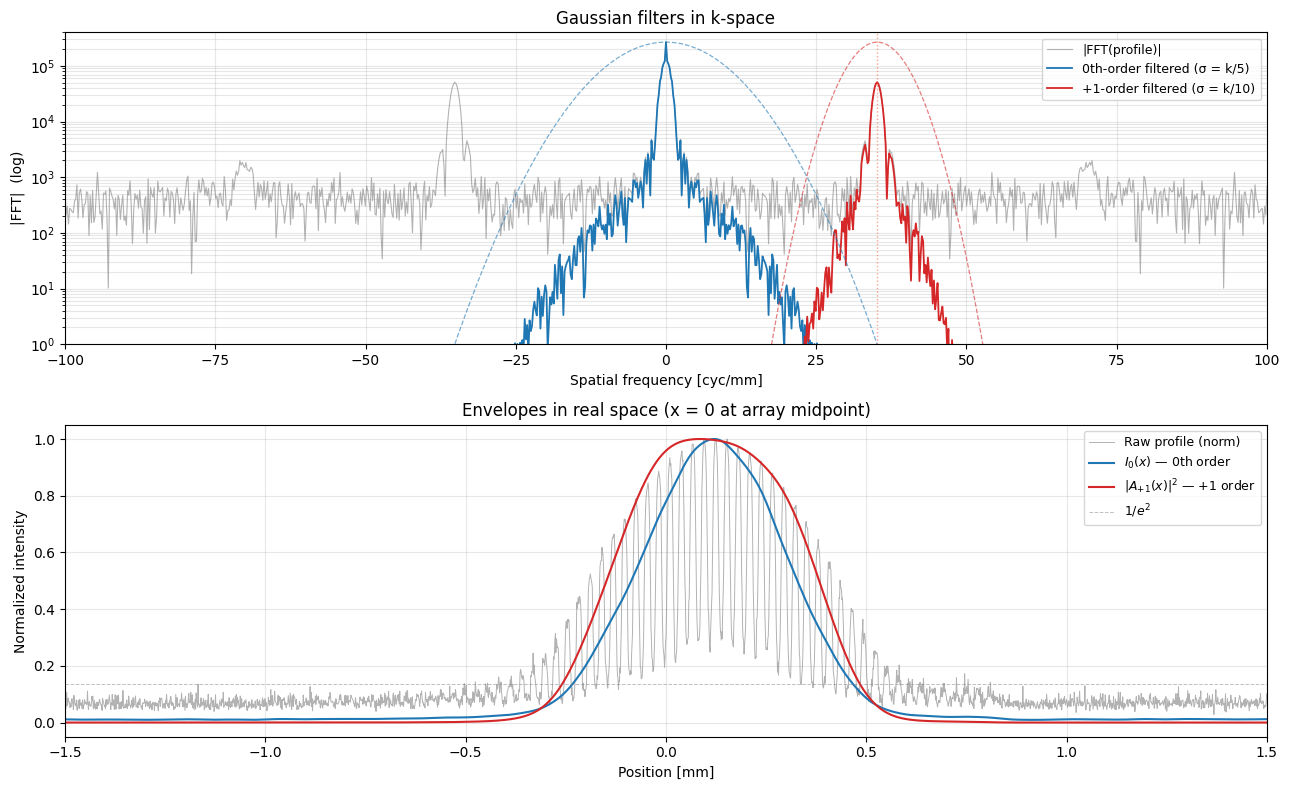

In [33]:
# Test extract_envelopes
env = extract_envelopes(carrier['fft_avg'], carrier['freq'], carrier['k_peak'],
                        sigma_ratio_0=5, sigma_ratio_1=10)

print(f"sigma_0 (0th order): {env['sigma_0']*1e-3:.2f} cyc/mm")
print(f"sigma_1 (+1 order) : {env['sigma_1']*1e-3:.2f} cyc/mm")
print(f"I0 range : [{env['I0'].min():.1f}, {env['I0'].max():.1f}]")
print(f"A1 range : [{env['A1'].min():.2f}, {env['A1'].max():.2f}]")

# --- Plot: k-space (filters + filtered FFTs) and real-space (I0, A1²) ---
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Top: k-space
ax = axes[0]
freq    = carrier['freq']
fft_avg = carrier['fft_avg']
peak    = np.abs(fft_avg).max()

ax.semilogy(freq * 1e-3, np.abs(fft_avg), 'gray', lw=0.8, alpha=0.6,
            label='|FFT(profile)|')
ax.semilogy(freq * 1e-3, np.abs(fft_avg * env['gauss_lp']), 'C0', lw=1.3,
            label=f'0th-order filtered (σ = k/{5})')
ax.semilogy(freq * 1e-3, np.abs(fft_avg * env['gauss_bp']), 'C3', lw=1.3,
            label=f'+1-order filtered (σ = k/{10})')
ax.plot(freq * 1e-3, env['gauss_lp']  * peak, 'C0', lw=0.9, ls='--', alpha=0.6)
ax.plot(freq * 1e-3, env['gauss_bp']  * peak, 'C3', lw=0.9, ls='--', alpha=0.6)
ax.axvline(carrier['k_peak']*1e-3, color='tomato', ls=':', lw=1, alpha=0.6)
ax.set_xlabel('Spatial frequency [cyc/mm]')
ax.set_ylabel('|FFT|  (log)')
ax.set_title('Gaussian filters in k-space')
ax.set_xlim(-100, 100)
ax.set_ylim(1e0, peak * 1.5)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, which='both', alpha=0.3)

# Bottom: real-space — raw, I0, A1²
ax = axes[1]
N    = len(profile)
x_mm = (np.arange(N) - N//2) * dx_m * 1e3

ax.plot(x_mm, profile / profile.max(),     'gray', lw=0.7, alpha=0.6,
        label='Raw profile (norm)')
ax.plot(x_mm, env['I0'] / env['I0'].max(), 'C0',   lw=1.5,
        label=r'$I_0(x)$ — 0th order')
ax.plot(x_mm, (env['A1']**2) / (env['A1']**2).max(), 'C3', lw=1.5,
        label=r'$|A_{+1}(x)|^2$ — +1 order')
ax.axhline(np.exp(-2), color='gray', ls='--', lw=0.7, alpha=0.5,
           label=r'$1/e^2$')
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Normalized intensity')
ax.set_title('Envelopes in real space (x = 0 at array midpoint)')
ax.set_xlim(-1.5, 1.5)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
def fill_mask_gaps(mask):
    """Fill False gaps between the leftmost and rightmost True values.

    A "trust region" beam mask should be a single contiguous block —
    if the threshold criterion (e.g. I0 > threshold) has small dips
    in the middle of the beam, fill_mask_gaps closes them.

    Parameters
    ----------
    mask : array_like of bool, shape (N,)
        Boolean mask, typically from I0 > threshold.

    Returns
    -------
    filled : ndarray of bool, shape (N,)
        Mask with all False values between the first and last True
        promoted to True. Returns the input unchanged if mask is all False.
    """
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return mask.copy()
    i_first = np.argmax(mask)              # first True
    i_last  = len(mask) - 1 - np.argmax(mask[::-1])   # last True
    filled = mask.copy()
    filled[i_first:i_last+1] = True
    return filled


In [35]:
# Test fill_mask_gaps with a synthetic mask with gaps
test_mask = np.array([False, False, True, True, False, True, False, True, True, False, False])
print("input :", test_mask.astype(int))
print("output:", fill_mask_gaps(test_mask).astype(int))
# expected: 0 0 1 1 1 1 1 1 1 0 0

# Edge cases
print("all False :", fill_mask_gaps(np.zeros(5, bool)).astype(int))   # 0 0 0 0 0
print("all True  :", fill_mask_gaps(np.ones(5, bool)).astype(int))    # 1 1 1 1 1
print("single Tr :", fill_mask_gaps(np.array([False, True, False])).astype(int))  # 0 1 0

input : [0 0 1 1 0 1 0 1 1 0 0]
output: [0 0 1 1 1 1 1 1 1 0 0]
all False : [0 0 0 0 0]
all True  : [1 1 1 1 1]
single Tr : [0 1 0]


In [36]:
def find_phase_centroid(I0, A1, threshold=None):
    """Find the beam centroid for use as phase reference.

    Builds a beam mask from I0 > threshold * max(I0), fills gaps,
    then computes the centroid weighted by |A1|² inside that mask.

    Parameters
    ----------
    I0 : array_like, shape (N,)
        0th-order beam intensity (from extract_envelopes).
    A1 : array_like, shape (N,)
        +1-order fringe amplitude (from extract_envelopes).
    threshold : float, optional (default 1/e² ≈ 0.135)
        Fraction of I0 peak above which pixels are kept in the beam mask.

    Returns
    -------
    out : dict
        x_c          : int        centroid pixel index
        beam_mask    : ndarray    gap-filled boolean mask (N,)
        threshold    : float      threshold actually used
        n_mask_px    : int        number of True pixels in mask
        n_filled_px  : int        number of False→True conversions by gap-fill
    """
    if threshold is None:
        threshold = np.exp(-2)   # 1/e² ≈ 0.135

    I0 = np.asarray(I0, dtype=float)
    A1 = np.asarray(A1, dtype=float)

    raw_mask  = I0 > threshold * I0.max()
    beam_mask = fill_mask_gaps(raw_mask)

    if not beam_mask.any():
        raise ValueError(
            f"Beam mask is empty at threshold={threshold:.3g}. "
            f"Check I0 (max={I0.max():.3g}) or lower threshold."
        )

    weights = A1[beam_mask] ** 2
    x_idx   = np.arange(len(I0))
    x_c     = int(np.average(x_idx[beam_mask], weights=weights))

    return dict(
        x_c         = x_c,
        beam_mask   = beam_mask,
        threshold   = threshold,
        n_mask_px   = int(beam_mask.sum()),
        n_filled_px = int(beam_mask.sum() - raw_mask.sum()),
    )


Threshold used     : 0.1353  (= 1/e²)
Mask pixels        : 578 px  (0 added by gap-fill)
Centroid pixel x_c : 2151
Centroid position  : x = +0.1150 mm
Array midpoint     : x = +0.0000 mm
Offset (centroid − midpoint): +0.1150 mm


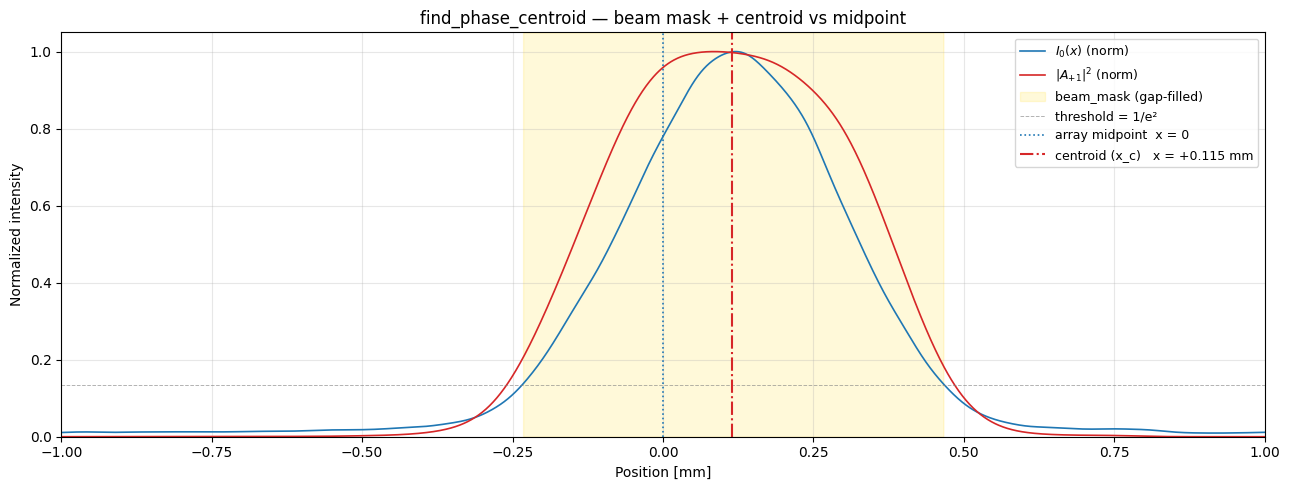

In [37]:
# Test find_phase_centroid
centroid = find_phase_centroid(env['I0'], env['A1'])

print(f"Threshold used     : {centroid['threshold']:.4f}  (= 1/e²)")
print(f"Mask pixels        : {centroid['n_mask_px']} px  "
      f"({centroid['n_filled_px']} added by gap-fill)")
print(f"Centroid pixel x_c : {centroid['x_c']}")

N    = len(profile)
x_mm = (np.arange(N) - N//2) * dx_m * 1e3
print(f"Centroid position  : x = {x_mm[centroid['x_c']]:+.4f} mm")
print(f"Array midpoint     : x = {x_mm[N//2]:+.4f} mm")
print(f"Offset (centroid − midpoint): {x_mm[centroid['x_c']] - x_mm[N//2]:+.4f} mm")

# Plot: I0, A1², mask, midpoint vs centroid
fig, ax = plt.subplots(figsize=(13, 5))

I0_n = env['I0'] / env['I0'].max()
A1sq_n = (env['A1']**2) / (env['A1']**2).max()

ax.plot(x_mm, I0_n,   'C0', lw=1.2, label=r'$I_0(x)$ (norm)')
ax.plot(x_mm, A1sq_n, 'C3', lw=1.2, label=r'$|A_{+1}|^2$ (norm)')
ax.fill_between(x_mm, 0, 1.05, where=centroid['beam_mask'],
                color='gold', alpha=0.15, label='beam_mask (gap-filled)')
ax.axhline(centroid['threshold'], color='gray', ls='--', lw=0.7, alpha=0.6,
           label=f'threshold = 1/e²')
ax.axvline(x_mm[N//2],         color='C0', ls=':', lw=1.2,
           label=f'array midpoint  x = 0')
ax.axvline(x_mm[centroid['x_c']], color='C3', ls='-.', lw=1.5,
           label=f"centroid (x_c)   x = {x_mm[centroid['x_c']]:+.3f} mm")

ax.set_xlabel('Position [mm]')
ax.set_ylabel('Normalized intensity')
ax.set_title('find_phase_centroid — beam mask + centroid vs midpoint')
ax.set_xlim(-1, 1)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
def reconstruct_wavefront(complex_1st, dx, grating_pitch, wavelength, z_gd, x_c):
    """Reconstruct wavefront W(x) in radians from the +1-order complex envelope.

    Implements the corrected May-2026 pipeline:
        1. Unwrap phase of complex_1st.
        2. Center unwrapped phase at x_c (beam centroid, not array midpoint).
        3. Subtract ideal carrier ramp 2π/p · (x − x[x_c]).
        4. Cumulative-integrate the differential phase.
        5. Re-center result at x_c.

    Parameters
    ----------
    complex_1st : ndarray (N,) complex
        +1-order complex envelope (from extract_envelopes).
    dx : float [m]
        Pixel pitch.
    grating_pitch : float [m]
        Ideal grating pitch (used for the carrier ramp, NOT the filter).
    wavelength : float [m]
        X-ray wavelength.
    z_gd : float [m]
        Grating-to-detector distance.
    x_c : int
        Phase reference pixel index (from find_phase_centroid).

    Returns
    -------
    out : dict
        W_rad        : ndarray (N,) [rad]   Reconstructed W(x), centered at x_c
        delta_phi    : ndarray (N,) [rad]   Differential phase after carrier removal
        phase_unwrap : ndarray (N,) [rad]   Unwrapped phase, centered at x_c
        x_m          : ndarray (N,) [m]     Spatial coordinate (x = 0 at x_c)
        carrier_ramp : ndarray (N,) [rad]   Ideal carrier ramp (for diagnostics)
    """
    N = len(complex_1st)

    # Spatial coordinate: x = 0 at the phase centroid
    x_m = (np.arange(N) - x_c) * dx

    # 1. Unwrap and re-center at x_c
    phase_unwrap = np.unwrap(np.angle(complex_1st))
    phase_unwrap = phase_unwrap - phase_unwrap[x_c]

    # 2. Ideal carrier ramp (centered at x_c, so it's zero there)
    carrier_ramp = 2 * np.pi / grating_pitch * x_m

    # 3. Differential phase
    delta_phi = phase_unwrap - carrier_ramp

    # 4. Integrate (sign follows May 19 convention; flip if your +1/−1 order differs)
    W_temp = -np.cumsum(delta_phi) * dx * grating_pitch / wavelength / z_gd

    # 5. Re-center at x_c
    W_rad = W_temp - W_temp[x_c]

    return dict(
        W_rad        = W_rad,
        delta_phi    = delta_phi,
        phase_unwrap = phase_unwrap,
        x_m          = x_m,
        carrier_ramp = carrier_ramp,
    )


Wavelength: 2.0426 nm  (607 eV)
z_gd:       400 mm

W(x) PV  (full array) : 1960.09 nm
W(x) RMS (full array) : 535.72 nm

Within beam_mask (578 px):
  PV  : 35.01 nm
  RMS : 10.33 nm


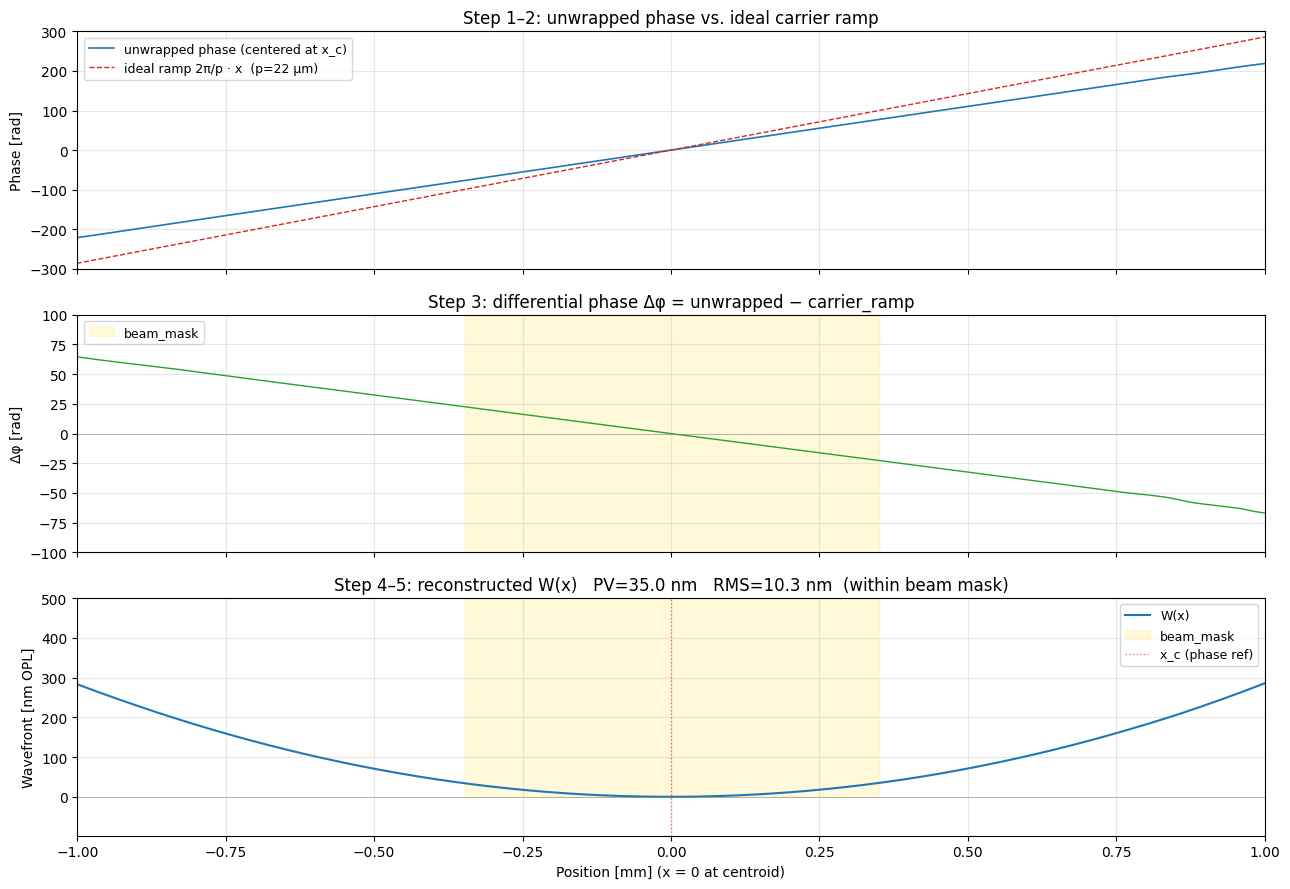

In [39]:
# Test reconstruct_wavefront on the old TIFF
z_gd_old_m = 0.4    # [m]  grating-to-detector distance for WFS210515-0002 campaign

print(f"Wavelength: {wavelength_m*1e9:.4f} nm  ({energy_eV} eV)")
print(f"z_gd:       {z_gd_old_m*1e3:.0f} mm")

# Run the reconstruction
wfr = reconstruct_wavefront(
    env['complex_1st'], dx_m, grating_pitch_m, wavelength_m, z_gd_old_m,
    x_c=centroid['x_c'],
)

# Convert to nm OPL for plotting
W_nm = wfr['W_rad'] * wavelength_m / (2*np.pi) * 1e9

print(f"\nW(x) PV  (full array) : {W_nm.max() - W_nm.min():.2f} nm")
print(f"W(x) RMS (full array) : {np.std(W_nm):.2f} nm")

# Print PV/RMS within the beam mask (more meaningful)
m = centroid['beam_mask']
print(f"\nWithin beam_mask ({m.sum()} px):")
print(f"  PV  : {W_nm[m].max() - W_nm[m].min():.2f} nm")
print(f"  RMS : {np.std(W_nm[m]):.2f} nm")

# Three-panel diagnostic plot
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
x_mm = wfr['x_m'] * 1e3

# Panel 1: unwrapped phase + carrier ramp
ax = axes[0]
ax.plot(x_mm, wfr['phase_unwrap'], 'C0', lw=1.2, label='unwrapped phase (centered at x_c)')
ax.plot(x_mm, wfr['carrier_ramp'], 'C3', lw=1.0, ls='--',
        label=f'ideal ramp 2π/p · x  (p={grating_pitch_m*1e6:.0f} µm)')
ax.set_ylabel('Phase [rad]')
ax.set_ylim(-300, 300)
ax.set_title('Step 1–2: unwrapped phase vs. ideal carrier ramp')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

# Panel 2: differential phase
ax = axes[1]
ax.plot(x_mm, wfr['delta_phi'], 'C2', lw=1.0)
ax.fill_between(x_mm, wfr['delta_phi'].min(), wfr['delta_phi'].max(),
                where=m, color='gold', alpha=0.15, label='beam_mask')
ax.axhline(0, color='gray', lw=0.7, alpha=0.5)
ax.set_ylabel('Δφ [rad]')
ax.set_ylim(-100, 100)
ax.set_title('Step 3: differential phase Δφ = unwrapped − carrier_ramp')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

# Panel 3: reconstructed wavefront
ax = axes[2]
ax.plot(x_mm, W_nm, 'C0', lw=1.5, label='W(x)')
ax.fill_between(x_mm, W_nm.min(), W_nm.max(),
                where=m, color='gold', alpha=0.15, label='beam_mask')
ax.axhline(0, color='gray', lw=0.7, alpha=0.5)
ax.axvline(0, color='C3', ls=':', lw=1, alpha=0.6, label='x_c (phase ref)')
ax.set_xlabel('Position [mm] (x = 0 at centroid)')
ax.set_ylabel('Wavefront [nm OPL]')
ax.set_title(f'Step 4–5: reconstructed W(x)   '
             f'PV={W_nm[m].max()-W_nm[m].min():.1f} nm   '
             f'RMS={np.std(W_nm[m]):.1f} nm  (within beam mask)')
ax.set_xlim(-1, 1)
ax.set_ylim(top=500)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [40]:
def parabolic_focal_fit(W_rad, x_m, wavelength, mask=None):
    """Fit a parabola to W(x) and predict focal length from defocus.

    For a converging wave, W(x) = -k x² / (2f) where k = 2π/λ.
    Fitting W = a₂ x² + a₁ x + a₀ gives:
        f_pred = -k / (2 a₂)
    Positive f_pred  → focus is downstream of the detector (converging beam).
    Negative f_pred  → focus is upstream (diverging or virtual focus).

    Parameters
    ----------
    W_rad : array_like (N,)  [rad]
        Wavefront from reconstruct_wavefront.
    x_m : array_like (N,)  [m]
        Spatial coordinate (x = 0 at the phase centroid).
    wavelength : float  [m]
        X-ray wavelength.
    mask : array_like (N,) of bool, optional
        Fit region. If None, fits over the entire array.

    Returns
    -------
    out : dict
        f_pred           : float [m]    Predicted focal length offset
        a2, a1, a0       : float        Polynomial coefficients (rad units)
        W_para_rad       : ndarray (N,) [rad]   Fitted parabola
        W_resid_rad      : ndarray (N,) [rad]   W − parabola (residual aberration)
        rms_resid_nm     : float [nm]   RMS of residual inside the mask
        pv_resid_nm      : float [nm]   PV of residual inside the mask
    """
    W_rad = np.asarray(W_rad)
    x_m   = np.asarray(x_m)

    if mask is None:
        mask = np.ones_like(W_rad, dtype=bool)

    # Fit parabola inside mask only
    a2, a1, a0 = np.polyfit(x_m[mask], W_rad[mask], 2)

    # Evaluate fit and residual everywhere
    W_para_rad  = a2 * x_m**2 + a1 * x_m + a0
    W_resid_rad = W_rad - W_para_rad

    # Predicted focal length offset (uses defocus coefficient a2)
    k = 2 * np.pi / wavelength
    f_pred = -k / (2 * a2)

    # Residual statistics inside the mask (the meaningful region)
    W_resid_nm   = W_resid_rad * wavelength / (2 * np.pi) * 1e9
    rms_resid_nm = float(np.std(W_resid_nm[mask]))
    pv_resid_nm  = float(W_resid_nm[mask].max() - W_resid_nm[mask].min())

    return dict(
        f_pred       = f_pred,
        a2           = a2,
        a1           = a1,
        a0           = a0,
        W_para_rad   = W_para_rad,
        W_resid_rad  = W_resid_rad,
        rms_resid_nm = rms_resid_nm,
        pv_resid_nm  = pv_resid_nm,
    )


Predicted focal length offset : f_pred = -1.768 m
  (diverging — virtual focus UPSTREAM)

Defocus coefficient a₂ : +8.7011e+08 rad/m²

Residual aberration (inside beam_mask):
  RMS : 0.006 nm
  PV  : 0.027 nm

For comparison: Wojdyla 2018 reports 0.623 nm rms residual at 500 eV
                across a 1.5 mm beam (after tilt+defocus removal).


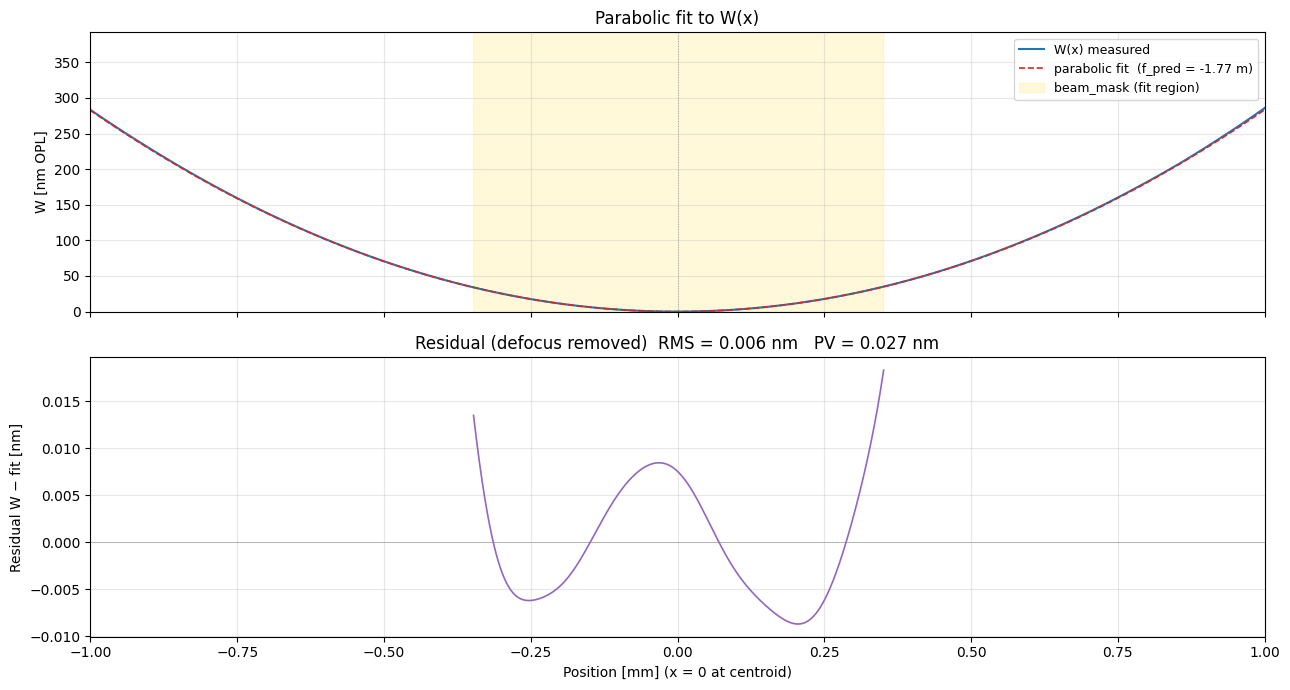

In [41]:
# Test parabolic_focal_fit
fit = parabolic_focal_fit(wfr['W_rad'], wfr['x_m'], wavelength_m,
                          mask=centroid['beam_mask'])

print(f"Predicted focal length offset : f_pred = {fit['f_pred']:+.3f} m")
print(f"  ({'converging — focus DOWNSTREAM of detector' if fit['f_pred'] > 0 else 'diverging — virtual focus UPSTREAM'})")
print(f"\nDefocus coefficient a₂ : {fit['a2']:+.4e} rad/m²")
print(f"\nResidual aberration (inside beam_mask):")
print(f"  RMS : {fit['rms_resid_nm']:.3f} nm")
print(f"  PV  : {fit['pv_resid_nm']:.3f} nm")
print(f"\nFor comparison: Wojdyla 2018 reports 0.623 nm rms residual at 500 eV")
print(f"                across a 1.5 mm beam (after tilt+defocus removal).")

# Convert to nm for plotting
W_nm       = wfr['W_rad']      * wavelength_m / (2*np.pi) * 1e9
W_para_nm  = fit['W_para_rad'] * wavelength_m / (2*np.pi) * 1e9
W_resid_nm = fit['W_resid_rad']* wavelength_m / (2*np.pi) * 1e9

# Two-panel plot
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
x_mm = wfr['x_m'] * 1e3
m    = centroid['beam_mask']

# Top: W(x), parabolic fit, beam mask
ax = axes[0]
ax.plot(x_mm, W_nm,      'C0', lw=1.5, label='W(x) measured')
ax.plot(x_mm, W_para_nm, 'C3', lw=1.2, ls='--',
        label=f'parabolic fit  (f_pred = {fit["f_pred"]:+.2f} m)')
ax.fill_between(x_mm, W_nm.min(), W_nm.max(),
                where=m, color='gold', alpha=0.15, label='beam_mask (fit region)')
ax.axvline(0, color='gray', ls=':', lw=0.7, alpha=0.6)
ax.set_ylabel('W [nm OPL]')
ax.set_ylim(W_nm.min(), W_nm.max()/5)
ax.set_title(f'Parabolic fit to W(x)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

# Bottom: residual
ax = axes[1]
# Show residual only inside mask; mask outside with NaN so the wild noise
# doesn't dominate the y-axis
W_resid_plot = np.where(m, W_resid_nm, np.nan)
ax.plot(x_mm, W_resid_plot, 'C4', lw=1.2)
ax.axhline(0, color='gray', lw=0.7, alpha=0.5)
ax.set_xlabel('Position [mm] (x = 0 at centroid)')
ax.set_ylabel('Residual W − fit [nm]')
ax.set_title(f'Residual (defocus removed)  '
             f'RMS = {fit["rms_resid_nm"]:.3f} nm   '
             f'PV = {fit["pv_resid_nm"]:.3f} nm')
ax.set_xlim(-1, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
import monoplus as mp   # already imported in your beamline env

def propagate_to_focus(A, W_rad, dx, wavelength, z_range_m, x_m=None):
    """Fresnel-propagate the reconstructed field to find the focus.

    Constructs the field at the detector plane
        E_det(x) = A(x) · exp[i W(x)]
    and propagates it over a range of z values using monoplus.propTF.
    The focus is identified as the z at which the RMS beam size σ(z)
    is minimum.

    Parameters
    ----------
    A : array_like (N,)  [a.u.]
        Field amplitude at the detector plane. Use A1 from extract_envelopes
        — it naturally tapers to ~0 outside the beam, which suppresses
        edge-diffraction artifacts during propagation.
    W_rad : array_like (N,)  [rad]
        Reconstructed wavefront (from reconstruct_wavefront).
    dx : float  [m]
        Pixel pitch.
    wavelength : float  [m]
        X-ray wavelength.
    z_range_m : array_like  [m]
        Propagation distances to evaluate. e.g. np.linspace(-3, 3, 601).
    x_m : array_like (N,) [m], optional
        Spatial coordinate — needed for σ_rms computation. If None,
        uses (np.arange(N) - N//2) * dx.

    Returns
    -------
    out : dict
        E_caustic     : ndarray (N, Z) complex   field at each z
        I_caustic     : ndarray (N, Z)           |E|² intensity caustic
        sigma_rms     : ndarray (Z,) [m]         σ_rms vs z
        z_range_m     : ndarray (Z,) [m]
        z_focus       : float [m]                z minimizing σ_rms
        sigma_focus   : float [m]                σ_rms at focus
        i_focus       : int                       index of focus in z_range_m
        E_focus       : ndarray (N,) complex     field at focus
        I_focus       : ndarray (N,)             |E|² at focus
    """
    N = len(A)
    if x_m is None:
        x_m = (np.arange(N) - N // 2) * dx

    L_m = N * dx                      # physical array length

    # Build detector-plane complex field
    E_det = A * np.exp(1j * W_rad)

    # Propagate over z_range
    z_range_m = np.asarray(z_range_m, dtype=float)
    Z = len(z_range_m)

    E_caustic = np.zeros((N, Z), dtype=complex)
    for i_z, z in enumerate(z_range_m):
        E_caustic[:, i_z] = mp.propTF(E_det, L_m, wavelength, z)

    I_caustic = np.abs(E_caustic)**2
    sigma_rms = mp.secondmomt(Z, x_m, E_caustic)

    # Locate focus
    i_focus     = int(np.argmin(sigma_rms))
    z_focus     = float(z_range_m[i_focus])
    sigma_focus = float(sigma_rms[i_focus])

    return dict(
        E_caustic   = E_caustic,
        I_caustic   = I_caustic,
        sigma_rms   = sigma_rms,
        z_range_m   = z_range_m,
        z_focus     = z_focus,
        sigma_focus = sigma_focus,
        i_focus     = i_focus,
        E_focus     = E_caustic[:, i_focus],
        I_focus     = I_caustic[:, i_focus],
    )


In [43]:
def wavefront_at_focus(prop, wavelength, dx, threshold=None):
    """Extract the wavefront W(x) at the focus, restricted to the focal spot.

    The focal spot is defined as |E_focus|² > threshold·max(|E_focus|²),
    with gap-filling. The wavefront is the unwrapped phase of E_focus,
    centered at the intensity centroid of the focus.

    Parameters
    ----------
    prop : dict
        Output of propagate_to_focus.
    wavelength : float [m]
        X-ray wavelength (for nm conversion).
    dx : float [m]
        Pixel pitch.
    threshold : float, optional (default 1/e²)
        Intensity-mask threshold for the focal spot.

    Returns
    -------
    out : dict
        W_focus_rad     : ndarray (N,) [rad]   unwrapped phase at focus, centered
        W_focus_nm      : ndarray (N,) [nm]    W_focus_rad in nm OPL
        focus_mask      : ndarray (N,) of bool gap-filled focal-spot mask
        x_c_focus       : int                   centroid pixel of focus intensity
        rms_at_focus_nm : float [nm]            RMS inside focus_mask
        pv_at_focus_nm  : float [nm]            PV  inside focus_mask
    """
    if threshold is None:
        threshold = np.exp(-2)

    E = prop['E_focus']
    I = prop['I_focus']
    N = len(E)

    # Focus mask: intensity > threshold × peak, gap-filled
    raw_mask    = I > threshold * I.max()
    focus_mask  = fill_mask_gaps(raw_mask)

    if not focus_mask.any():
        raise ValueError("Empty focus mask — lower threshold or check propagation result.")

    # Centroid of focus intensity (use I-weighting, not A²-weighting,
    # since at focus there's no separate fringe-amplitude concept)
    x_idx     = np.arange(N)
    x_c_focus = int(np.average(x_idx[focus_mask], weights=I[focus_mask]))

    # Unwrap phase and center at the focus centroid
    W_focus_rad = np.unwrap(np.angle(E))
    W_focus_rad = W_focus_rad - W_focus_rad[x_c_focus]

    # nm conversion
    W_focus_nm = W_focus_rad * wavelength / (2 * np.pi) * 1e9

    # Statistics inside focus mask
    rms_at_focus_nm = float(np.std(W_focus_nm[focus_mask]))
    pv_at_focus_nm  = float(W_focus_nm[focus_mask].max() - W_focus_nm[focus_mask].min())

    return dict(
        W_focus_rad     = W_focus_rad,
        W_focus_nm      = W_focus_nm,
        focus_mask      = focus_mask,
        x_c_focus       = x_c_focus,
        rms_at_focus_nm = rms_at_focus_nm,
        pv_at_focus_nm  = pv_at_focus_nm,
    )


Predicted focus (parabolic) : f_pred  = -1.768 m
Scanning z range            : [-3.77, +0.23] m  (201 pts, step = 20.0 mm)

Found focus (σ_rms minimum) : z_focus = -1.788 m
σ_rms at focus              : 28.84 µm
Agreement |z_focus − f_pred|: 20 mm  (1.1%)

Wavefront at focus (inside focus_mask, 8 px):
  RMS : 0.094 nm
  PV  : 0.262 nm


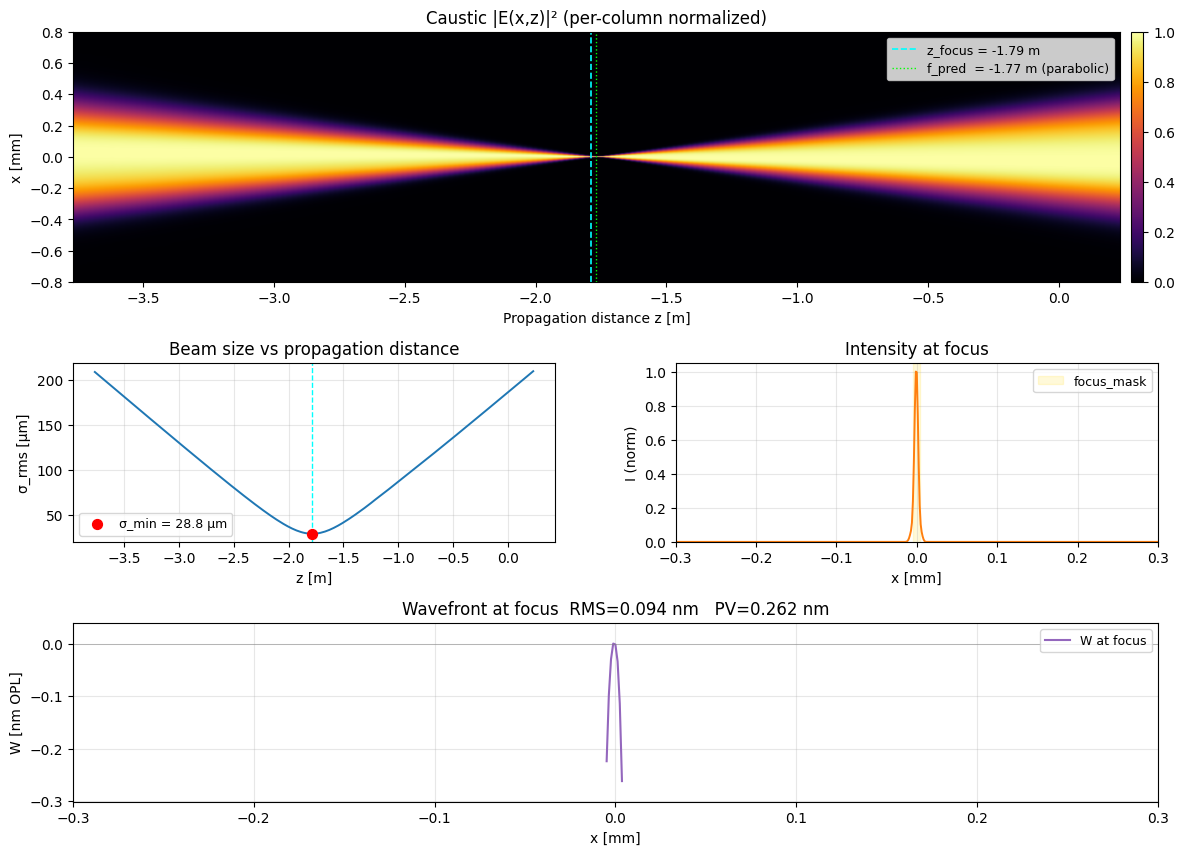

In [44]:
# Auto z-range from f_pred
half_width = max(abs(fit['f_pred']), 2.0)   # at least ±2 m, more if f_pred is large
z_range_m  = np.linspace(fit['f_pred'] - half_width,
                         fit['f_pred'] + half_width, int(half_width/0.02)*2+1)

print(f"Predicted focus (parabolic) : f_pred  = {fit['f_pred']:+.3f} m")
print(f"Scanning z range            : [{z_range_m[0]:+.2f}, {z_range_m[-1]:+.2f}] m  "
      f"({len(z_range_m)} pts, step = {(z_range_m[1]-z_range_m[0])*1e3:.1f} mm)")

prop = propagate_to_focus(
    env['A1'], wfr['W_rad'], dx_m, wavelength_m, z_range_m,
    x_m=wfr['x_m'],
)

print(f"\nFound focus (σ_rms minimum) : z_focus = {prop['z_focus']:+.3f} m")
print(f"σ_rms at focus              : {prop['sigma_focus']*1e6:.2f} µm")
print(f"Agreement |z_focus − f_pred|: {abs(prop['z_focus'] - fit['f_pred'])*1e3:.0f} mm  "
      f"({abs(prop['z_focus'] - fit['f_pred'])/abs(fit['f_pred'])*100:.1f}%)")

# Wavefront at the focus
wff = wavefront_at_focus(prop, wavelength_m, dx_m)
print(f"\nWavefront at focus (inside focus_mask, {wff['focus_mask'].sum()} px):")
print(f"  RMS : {wff['rms_at_focus_nm']:.3f} nm")
print(f"  PV  : {wff['pv_at_focus_nm']:.3f} nm")

# --- Plot: caustic, σ_rms(z), focus intensity, focus W(x) ---
fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(3, 2, hspace=0.40, wspace=0.25,
                       height_ratios=[1.4, 1, 1])

x_mm = wfr['x_m'] * 1e3

# Panel 1 (top, spans both columns): caustic
ax = fig.add_subplot(gs[0, :])
I_norm = prop['I_caustic'] / prop['I_caustic'].max(axis=0, keepdims=True)
im = ax.imshow(I_norm,
               extent=(z_range_m[0], z_range_m[-1], x_mm[0], x_mm[-1]),
               aspect='auto', origin='lower', cmap='inferno')
ax.axvline(prop['z_focus'], color='cyan', lw=1.2, ls='--',
           label=f'z_focus = {prop["z_focus"]:+.2f} m')
ax.axvline(fit['f_pred'], color='lime', lw=1.0, ls=':',
           label=f'f_pred  = {fit["f_pred"]:+.2f} m (parabolic)')
ax.set_xlabel('Propagation distance z [m]')
ax.set_ylabel('x [mm]')
ax.set_title('Caustic |E(x,z)|² (per-column normalized)')
ax.set_ylim(-0.8, 0.8)
ax.legend(loc='upper right', fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.01)

# Panel 2 (middle left): σ_rms(z)
ax = fig.add_subplot(gs[1, 0])
ax.plot(z_range_m, prop['sigma_rms']*1e6, 'C0', lw=1.4)
ax.axvline(prop['z_focus'], color='cyan', lw=1.0, ls='--')
ax.scatter([prop['z_focus']], [prop['sigma_focus']*1e6],
           color='red', s=50, zorder=5,
           label=f"σ_min = {prop['sigma_focus']*1e6:.1f} µm")
ax.set_xlabel('z [m]')
ax.set_ylabel('σ_rms [µm]')
ax.set_title('Beam size vs propagation distance')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 3 (middle right): intensity at focus
ax = fig.add_subplot(gs[1, 1])
ax.plot(x_mm, prop['I_focus'] / prop['I_focus'].max(), 'C1', lw=1.4)
ax.fill_between(x_mm, 0, 1.05, where=wff['focus_mask'],
                color='gold', alpha=0.15, label='focus_mask')
ax.set_xlabel('x [mm]')
ax.set_ylabel('I (norm)')
ax.set_title(f'Intensity at focus')
ax.set_xlim(-0.3, 0.3)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

# Panel 4 (bottom, spans both cols): wavefront at focus
ax = fig.add_subplot(gs[2, :])
m_f = wff['focus_mask']
W_focus_plot = np.where(m_f, wff['W_focus_nm'], np.nan)
ax.plot(x_mm, W_focus_plot, 'C4', lw=1.5)
ax.axhline(0, color='gray', lw=0.7, alpha=0.5)
ax.set_xlabel('x [mm]')
ax.set_ylabel('W [nm OPL]')
ax.set_title(f'Wavefront at focus  '
             f'RMS={wff["rms_at_focus_nm"]:.3f} nm   '
             f'PV={wff["pv_at_focus_nm"]:.3f} nm')
ax.set_xlim(-0.3, 0.3)
if m_f.any():
    lo = np.nanmin(W_focus_plot); hi = np.nanmax(W_focus_plot)
    rng = max(hi - lo, 0.01)
    ax.set_ylim(lo - 0.15*rng, hi + 0.15*rng)
ax.legend(['W at focus'], fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

plt.show()

## Combined 

In [45]:
def reconstruct_single(
    image_or_profile,
    dx, grating_pitch, wavelength, z_gd,
    *,
    y_roi=None, axis=1,
    band_factor=1.5,
    sigma_ratio_0=5, sigma_ratio_1=10,
    centroid_threshold=None,
    fit_order=2,
    propagate=False,
    z_range_m=None,
    focus_threshold=None,
    k_amp_good=2000, k_amp_bad=500,
    verbose=False,
):
    """Full single-frame WFS pipeline: image → wavefront (+ optional propagation).

    Steps:
        1. extract_profile (if 2-D input)
        2. find_carrier
        3. extract_envelopes
        4. find_phase_centroid
        5. reconstruct_wavefront
        6. parabolic_focal_fit
        7. (optional) propagate_to_focus + wavefront_at_focus

    Parameters
    ----------
    image_or_profile : ndarray
        Either a 2-D detector image (will be reduced to 1-D via y_roi),
        or an already-extracted 1-D fringe profile.
    dx, grating_pitch, wavelength, z_gd : float
        Required physical parameters [m].
    y_roi : slice, optional
        Required if image_or_profile is 2-D; passed to extract_profile.
    axis : int
        Averaging axis for extract_profile (1 = average over columns/rows
        depending on convention). Default 1.
    band_factor : float
        Carrier search half-band width factor (search = 1/p / f to 1/p * f).
    sigma_ratio_0, sigma_ratio_1 : float
        Gaussian filter widths in units of k_peak.
    centroid_threshold : float
        I0 mask threshold (default 1/e²).
    fit_order : int
        Polynomial order for parabolic_focal_fit (currently only 2 supported).
    propagate : bool
        If True, run steps 8a + 8b (propagation + W at focus).
    z_range_m : array_like, optional
        Custom z range for propagation. If None, auto-set from f_pred.
    focus_threshold : float
        Focus mask threshold (default 1/e²).
    k_amp_good, k_amp_bad : float
        Quality thresholds on carrier amplitude:
        - amp >= k_amp_good → 'good'
        - k_amp_bad <= amp < k_amp_good → 'ok'
        - amp < k_amp_bad → 'bad' (likely near-focus, no fringes)
    verbose : bool
        Print a one-line summary.

    Returns
    -------
    result : dict
        Flat dict containing keys from all pipeline stages, plus:
        - quality : 'good' / 'ok' / 'bad'
        - W_nm    : reconstructed W in nm OPL (convenience)
        - x_mm    : x_m in mm (convenience)
    """
    arr = np.asarray(image_or_profile, dtype=float)

    # --- Step 1: profile ---
    if arr.ndim == 2:
        if y_roi is None:
            raise ValueError("y_roi is required for 2-D input.")
        profile = extract_profile(arr, y_roi, axis=axis)
    elif arr.ndim == 1:
        profile = arr
    else:
        raise ValueError(f"image_or_profile must be 1-D or 2-D, got {arr.ndim}-D.")

    # --- Step 2: carrier ---
    car = find_carrier(profile, dx, grating_pitch, band_factor=band_factor)

    # --- Quality flag based on carrier amplitude ---
    if car['k_amp'] >= k_amp_good:
        quality = 'good'
    elif car['k_amp'] >= k_amp_bad:
        quality = 'ok'
    else:
        quality = 'bad'

    # --- Step 3: envelopes ---
    env = extract_envelopes(car['fft_avg'], car['freq'], car['k_peak'],
                            sigma_ratio_0=sigma_ratio_0,
                            sigma_ratio_1=sigma_ratio_1)

    # --- Step 4: centroid ---
    cen = find_phase_centroid(env['I0'], env['A1'],
                              threshold=centroid_threshold)

    # --- Step 5: wavefront ---
    wfr = reconstruct_wavefront(env['complex_1st'], dx, grating_pitch,
                                   wavelength, z_gd, x_c=cen['x_c'])

    # --- Step 6: parabolic fit + f_pred ---
    fit = parabolic_focal_fit(wfr['W_rad'], wfr['x_m'], wavelength,
                              mask=cen['beam_mask'])

    # Convenience conversions
    W_nm = wfr['W_rad'] * wavelength / (2*np.pi) * 1e9
    x_mm = wfr['x_m'] * 1e3

    # In-mask statistics on the raw W (defocus-dominated)
    m = cen['beam_mask']
    rms_W_nm = float(np.std(W_nm[m]))
    pv_W_nm  = float(W_nm[m].max() - W_nm[m].min())

    result = dict(
        # raw inputs / step 1
        profile           = profile,
        # step 2
        k_peak            = car['k_peak'],
        k_amp             = car['k_amp'],
        k_ideal           = car['k_ideal'],
        fft_avg           = car['fft_avg'],
        freq              = car['freq'],
        carrier_band      = car['band'],
        quality           = quality,
        # step 3
        I0                = env['I0'],
        A1                = env['A1'],
        complex_0th       = env['complex_0th'],
        complex_1st       = env['complex_1st'],
        sigma_0           = env['sigma_0'],
        sigma_1           = env['sigma_1'],
        # step 4
        x_c               = cen['x_c'],
        beam_mask         = cen['beam_mask'],
        n_mask_px         = cen['n_mask_px'],
        # step 5
        W_rad             = wfr['W_rad'],
        W_nm              = W_nm,
        x_m               = wfr['x_m'],
        x_mm              = x_mm,
        delta_phi         = wfr['delta_phi'],
        phase_unwrap      = wfr['phase_unwrap'],
        # step 6
        f_pred            = fit['f_pred'],
        a2                = fit['a2'],
        W_para_rad        = fit['W_para_rad'],
        W_resid_rad       = fit['W_resid_rad'],
        rms_resid_nm      = fit['rms_resid_nm'],
        pv_resid_nm       = fit['pv_resid_nm'],
        # raw stats
        rms_W_nm          = rms_W_nm,
        pv_W_nm           = pv_W_nm,
        # passed-through parameters
        dx                = dx,
        grating_pitch     = grating_pitch,
        wavelength        = wavelength,
        z_gd              = z_gd,
    )

    # --- Step 7: optional propagation ---
    if propagate:
        if z_range_m is None:
            half = max(abs(fit['f_pred']), 2.0)
            n_pts = int(half / 0.02) * 2 + 1   # ~20 mm step, odd count
            z_range_m = np.linspace(fit['f_pred'] - half,
                                    fit['f_pred'] + half, n_pts)
        prop = propagate_to_focus(env['A1'], wfr['W_rad'], dx, wavelength,
                                  z_range_m, x_m=wfr['x_m'])
        wff  = wavefront_at_focus(prop, wavelength, dx, threshold=focus_threshold)

        result.update(dict(
            # step 7
            z_range_m       = prop['z_range_m'],
            sigma_rms       = prop['sigma_rms'],
            z_focus         = prop['z_focus'],
            sigma_focus     = prop['sigma_focus'],
            i_focus         = prop['i_focus'],
            E_focus         = prop['E_focus'],
            I_focus         = prop['I_focus'],
            I_caustic       = prop['I_caustic'],
            # step 8
            W_focus_rad     = wff['W_focus_rad'],
            W_focus_nm      = wff['W_focus_nm'],
            focus_mask      = wff['focus_mask'],
            x_c_focus       = wff['x_c_focus'],
            rms_at_focus_nm = wff['rms_at_focus_nm'],
            pv_at_focus_nm  = wff['pv_at_focus_nm'],
        ))

    if verbose:
        msg = (f"[{quality:>4}]  λ={wavelength*1e9:.2f}nm  "
               f"k_peak={car['k_peak']*1e-3:.1f} cyc/mm  "
               f"k_amp={car['k_amp']:.0f}  "
               f"f_pred={fit['f_pred']:+.2f}m  "
               f"RMS_W={rms_W_nm:.1f}nm  RMS_resid={fit['rms_resid_nm']:.3f}nm")
        if propagate:
            msg += f"  z_focus={prop['z_focus']:+.2f}m  RMS@focus={wff['rms_at_focus_nm']:.3f}nm"
        print(msg)

    return result


In [46]:
# Full pipeline in one call, with propagation
result = reconstruct_single(
    im_arr, dx_m, grating_pitch_m, wavelength_m, z_gd_old_m,
    y_roi=y_roi_old, axis=axis_old,
    band_factor=1.5,
    propagate=True,
    verbose=True,
)

# Sanity check: does it match what we computed manually?
print(f"\n--- Self-consistency check ---")
print(f"x_c       : {result['x_c']}        (manual: {centroid['x_c']})")
print(f"k_peak    : {result['k_peak']*1e-3:.2f}    (manual: {carrier['k_peak']*1e-3:.2f}) cyc/mm")
print(f"f_pred    : {result['f_pred']:+.3f}    (manual: {fit['f_pred']:+.3f}) m")
print(f"z_focus   : {result['z_focus']:+.3f}    (manual: {prop['z_focus']:+.3f}) m")
print(f"RMS@focus : {result['rms_at_focus_nm']:.4f} (manual: {wff['rms_at_focus_nm']:.4f}) nm")

[good]  λ=2.04nm  k_peak=35.2 cyc/mm  k_amp=51023  f_pred=-1.77m  RMS_W=10.3nm  RMS_resid=0.006nm  z_focus=-1.79m  RMS@focus=0.094nm

--- Self-consistency check ---
x_c       : 2151        (manual: 2151)
k_peak    : 35.16    (manual: 35.16) cyc/mm
f_pred    : -1.768    (manual: -1.768) m
z_focus   : -1.788    (manual: -1.788) m
RMS@focus : 0.0938 (manual: 0.0938) nm


In [47]:
def plot_result(result, title='', figsize=None):
    """Diagnostic figure for a single-frame reconstruction.

    Panels (always shown):
        1. Fringe profile (raw)
        2. FFT |spectrum| with carrier and filters
        3. Envelopes I0, |A1|² and beam mask
        4. Wavefront W(x) with parabolic fit
        5. Residual (W − fit) inside beam mask

    Additional panels (if propagation was run):
        6. Caustic |E(x,z)|²
        7. σ_rms(z)
        8. Intensity at focus + wavefront at focus (twin y-axis)

    Parameters
    ----------
    result : dict
        Output of reconstruct_single.
    title : str
        Optional figure suptitle.
    figsize : tuple, optional
        Auto-sized if None.

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    has_prop = 'z_focus' in result

    if figsize is None:
        figsize = (14, 14) if has_prop else (14, 9)

    fig = plt.figure(figsize=figsize)
    n_rows = 5 if has_prop else 3
    gs = fig.add_gridspec(n_rows, 2, hspace=0.55, wspace=0.25)

    x_mm  = result['x_mm']
    N     = len(result['profile'])
    freq  = result['freq']
    m     = result['beam_mask']
    lam   = result['wavelength']

    # ─── Panel 1: raw fringe profile ─────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    x_full_mm = np.arange(N) * result['dx'] * 1e3
    ax.plot(x_full_mm, result['profile'], lw=0.7, color='steelblue')
    ax.axvline(x_full_mm[result['x_c']], color='C3', ls=':', lw=1,
               label=f"x_c (px {result['x_c']})")
    ax.set_xlabel('Position [mm]')
    ax.set_ylabel('Intensity [a.u.]')
    ax.set_title('Fringe profile')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

    # ─── Panel 2: FFT spectrum with carrier ──────────────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    ax.semilogy(freq * 1e-3, np.abs(result['fft_avg']), lw=0.8, color='steelblue',
                label='|FFT|')
    ax.axvspan(result['carrier_band'][0]*1e-3, result['carrier_band'][1]*1e-3,
               color='gold', alpha=0.2, label='search band')
    ax.axvline(result['k_ideal']*1e-3, color='red',    ls=':', lw=1,
               label=f"k_ideal={result['k_ideal']*1e-3:.1f}")
    ax.axvline(result['k_peak']*1e-3,  color='tomato', ls='--', lw=1.2,
               label=f"k_peak={result['k_peak']*1e-3:.1f}")
    ax.set_xlabel('Spatial frequency [cyc/mm]')
    ax.set_ylabel('|FFT| (log)')
    ax.set_title(f"FFT spectrum  (quality: {result['quality']}, k_amp={result['k_amp']:.0f})")
    ax.set_xlim(-result['k_ideal']*1e-3, 3*result['k_ideal']*1e-3)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, which='both', alpha=0.3)

    # ─── Panel 3: envelopes & beam mask ──────────────────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    I0_n   = result['I0'] / result['I0'].max()
    A1sq_n = (result['A1']**2) / (result['A1']**2).max()
    ax.plot(x_mm, I0_n,   'C0', lw=1.3, label=r'$I_0$ (norm)')
    ax.plot(x_mm, A1sq_n, 'C3', lw=1.3, label=r'$|A_{+1}|^2$ (norm)')
    ax.fill_between(x_mm, 0, 1.05, where=m, color='gold', alpha=0.15,
                    label='beam_mask')
    ax.axvline(0, color='C3', ls=':', lw=1, alpha=0.7)
    ax.set_xlabel('Position [mm] (x=0 at centroid)')
    ax.set_ylabel('Norm intensity')
    ax.set_title(f"Envelopes & beam mask  ({result['n_mask_px']} px)")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

    # ─── Panel 4: wavefront + parabolic fit ──────────────────────────────────
    ax = fig.add_subplot(gs[1, 1])
    W_para_nm = result['W_para_rad'] * lam / (2*np.pi) * 1e9
    W_plot      = np.where(m, result['W_nm'], np.nan)
    W_para_plot = np.where(m, W_para_nm,      np.nan)
    ax.plot(x_mm, result['W_nm'], 'C0', lw=0.6, alpha=0.3, label='W (outside)')
    ax.plot(x_mm, W_plot,         'C0', lw=1.5, label='W measured')
    ax.plot(x_mm, W_para_plot,    'C3', lw=1.2, ls='--',
            label=f"parabolic (f={result['f_pred']:+.2f} m)")
    if m.any():
        lo, hi = result['W_nm'][m].min(), result['W_nm'][m].max()
        rng = hi - lo if hi > lo else 1.0
        ylo, yhi = lo - 0.15*rng, hi + 0.15*rng
        ax.set_ylim(ylo, yhi)
        ax.fill_between(x_mm, ylo, yhi, where=m, color='gold', alpha=0.12)
        # X-limit: ±1.5 × beam_mask half-width
        x_beam = x_mm[m]
        x_half   = (x_beam.max() - x_beam.min()) / 2
        x_center = (x_beam.max() + x_beam.min()) / 2
        ax.set_xlim(x_center - 1.5*x_half, x_center + 1.5*x_half)
    ax.axvline(0, color='gray', ls=':', lw=0.7, alpha=0.6)
    ax.set_xlabel('Position [mm]')
    ax.set_ylabel('W [nm OPL]')
    ax.set_title('Wavefront')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

    # ─── Panel 5: residual (defocus removed) ─────────────────────────────────
    ax = fig.add_subplot(gs[2, :])
    W_resid_nm   = result['W_resid_rad'] * lam / (2*np.pi) * 1e9
    W_resid_plot = np.where(m, W_resid_nm, np.nan)
    ax.plot(x_mm, W_resid_plot, 'C4', lw=1.4)
    ax.axhline(0, color='gray', lw=0.7, alpha=0.5)
    ax.set_xlabel('Position [mm]')
    ax.set_ylabel('Residual [nm]')
    ax.set_title('Residual (defocus removed)')
    if m.any():
        lo, hi = W_resid_nm[m].min(), W_resid_nm[m].max()
        rng = max(hi - lo, 0.01)
        ax.set_ylim(lo - 0.2*rng, hi + 0.2*rng)
    ax.grid(alpha=0.3)

    # ─── Propagation panels (if available) ───────────────────────────────────
    if has_prop:
        z   = result['z_range_m']
        m_f = result['focus_mask']

        # Panel 6: caustic (full width)
        ax = fig.add_subplot(gs[3, :])
        I_norm = result['I_caustic'] / result['I_caustic'].max(axis=0, keepdims=True)
        im = ax.imshow(I_norm,
                       extent=(z[0], z[-1], x_mm[0], x_mm[-1]),
                       aspect='auto', origin='lower', cmap='inferno')
        ax.axvline(result['z_focus'], color='cyan', lw=1.2, ls='--',
                   label=f"z_focus = {result['z_focus']:+.2f} m")
        ax.axvline(result['f_pred'], color='lime',  lw=1.0, ls=':',
                   label=f"f_pred  = {result['f_pred']:+.2f} m")
        ax.set_xlabel('z [m]')
        ax.set_ylabel('x [mm]')
        ax.set_title('Caustic |E(x,z)|² (per-column normalized)')
        if m.any():
            x_beam = x_mm[m]
            ax.set_ylim(x_beam.min()*1.2, x_beam.max()*1.2)
        ax.legend(fontsize=8, loc='upper right')
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.01)

        # Panel 7: σ_rms(z)
        ax = fig.add_subplot(gs[4, 0])
        ax.plot(z, result['sigma_rms']*1e6, 'C0', lw=1.4)
        ax.axvline(result['z_focus'], color='cyan', lw=1, ls='--')
        ax.scatter([result['z_focus']], [result['sigma_focus']*1e6],
                   color='red', s=40, zorder=5,
                   label=f"σ_min = {result['sigma_focus']*1e6:.1f} µm")
        ax.set_xlabel('z [m]')
        ax.set_ylabel('σ_rms [µm]')
        ax.set_title('Beam size vs z')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # Panel 8: focus intensity + W at focus (twin axis)
        ax = fig.add_subplot(gs[4, 1])
        I_focus_norm = result['I_focus'] / result['I_focus'].max()
        ax.plot(x_mm, I_focus_norm, 'C1', lw=1.4, label='I (norm)')
        ax.fill_between(x_mm, 0, 1.05, where=m_f, color='gold', alpha=0.15)
        ax.set_xlabel('x [mm]')
        ax.set_ylabel('Norm intensity', color='C1')
        ax.tick_params(axis='y', labelcolor='C1')
        ax.set_ylim(0, 1.05)
        # X-limit: ±1.5 × focus_mask half-width
        if m_f.any():
            x_f = x_mm[m_f]
            x_half   = (x_f.max() - x_f.min()) / 2
            x_center = (x_f.max() + x_f.min()) / 2
            ax.set_xlim(x_center - 1.5*x_half, x_center + 1.5*x_half)

        # Wavefront on twin axis
        ax2 = ax.twinx()
        W_focus_plot = np.where(m_f, result['W_focus_nm'], np.nan)
        ax2.plot(x_mm, W_focus_plot, 'C4', lw=1.3, label='W at focus')
        ax2.set_ylabel('W at focus [nm]', color='C4')
        ax2.tick_params(axis='y', labelcolor='C4')
        if m_f.any():
            lo, hi = result['W_focus_nm'][m_f].min(), result['W_focus_nm'][m_f].max()
            rng = max(hi - lo, 0.01)
            ax2.set_ylim(lo - 0.3*rng, hi + 0.3*rng)

        ax.set_title('Focus')
        ax.grid(alpha=0.3)

    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=1)
    fig.subplots_adjust(top=0.95, bottom=0.05, left=0.07, right=0.96)
    plt.show()
    return fig


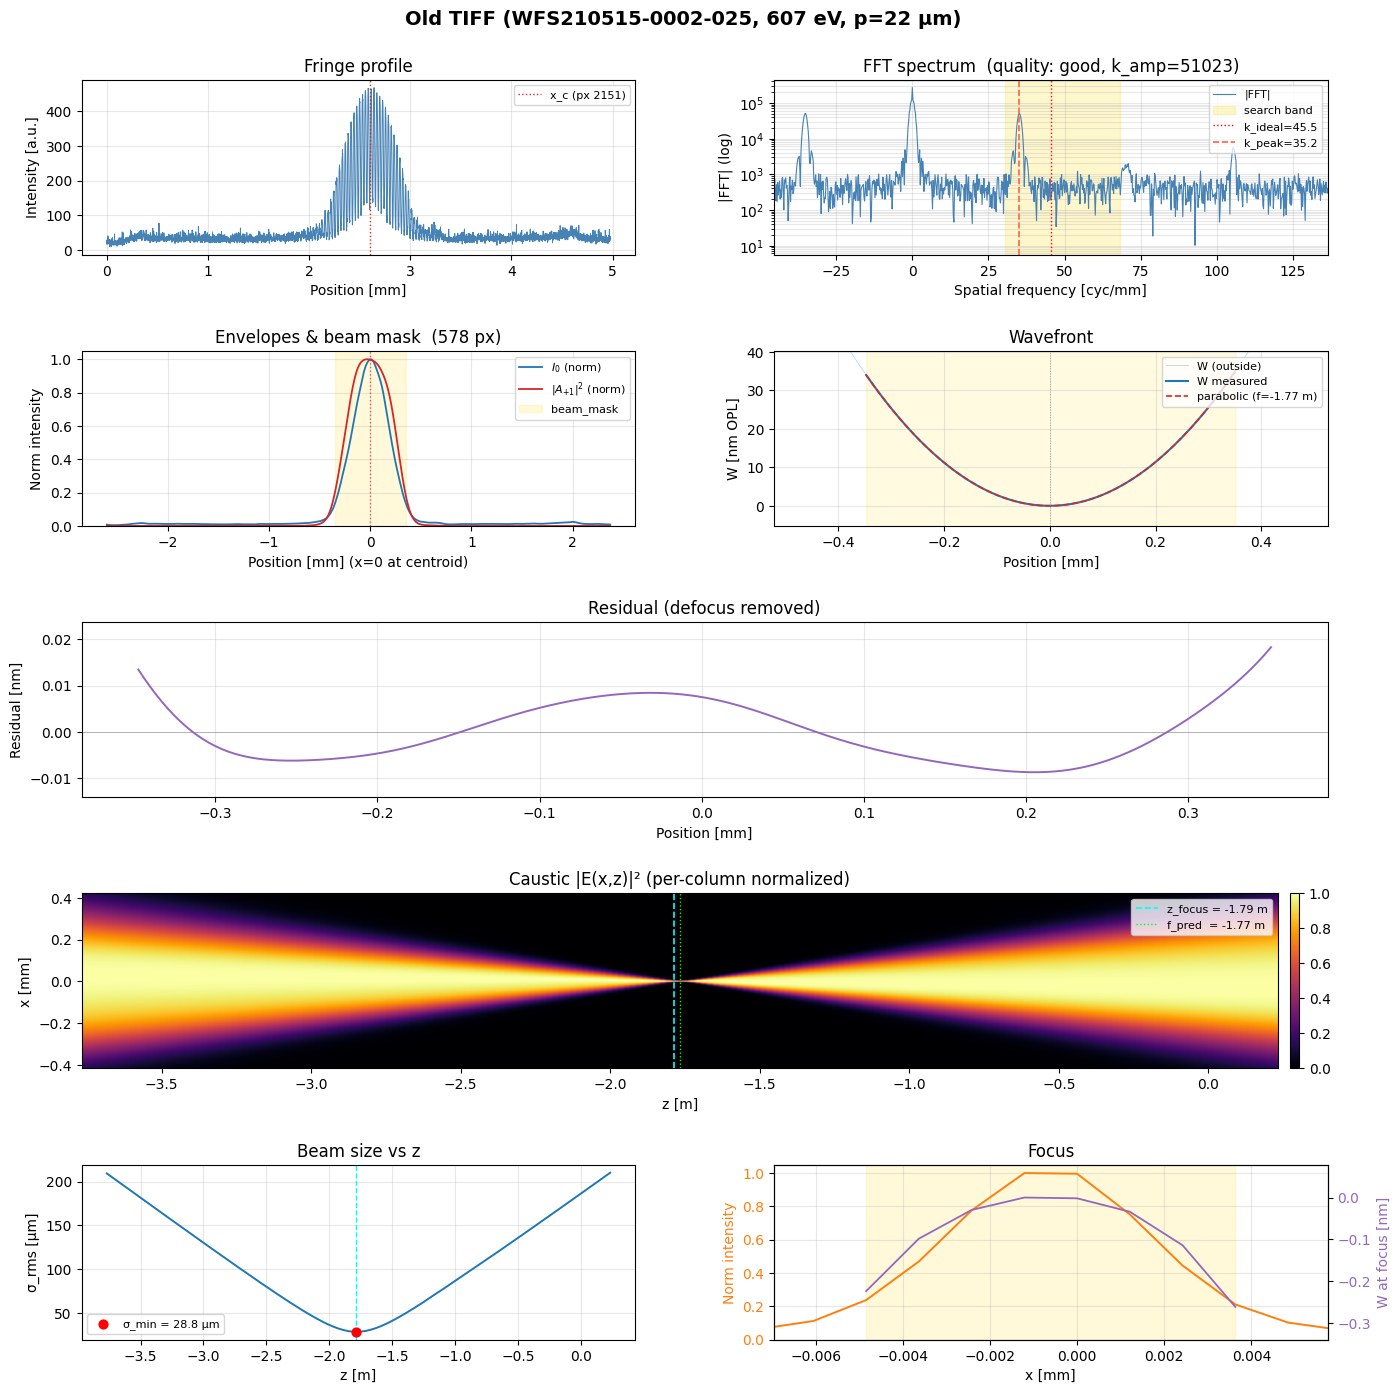

In [48]:
# Test plot_result with the existing result dict
_ = plot_result(result, title='Old TIFF (WFS210515-0002-025, 607 eV, p=22 µm)')

In [49]:
def quick_look(
    image_or_profile,
    dx, grating_pitch, wavelength, z_gd,
    *,
    y_roi=None, axis=1,
    propagate=False,
    title='',
    **kwargs,
):
    """One-call beamline workflow: image → reconstruction + diagnostic plot.

    Equivalent to:
        result = reconstruct_single(..., verbose=True, **kwargs)
        plot_result(result, title=title)
        return result

    Parameters
    ----------
    image_or_profile : ndarray
        2-D detector image or 1-D pre-extracted profile.
    dx, grating_pitch, wavelength, z_gd : float
        Physical parameters [m].
    y_roi : slice
        Required if input is 2-D.
    axis : int
        Averaging axis for extract_profile (default 1).
    propagate : bool
        If True, also propagate to find focus (~5–10 s overhead).
    title : str
        Figure suptitle.
    **kwargs
        Any other reconstruct_single kwargs (band_factor, sigma_ratio_0/1,
        centroid_threshold, k_amp_good/bad, z_range_m, ...).

    Returns
    -------
    result : dict
        Full reconstruct_single output dict.
    """
    result = reconstruct_single(
        image_or_profile,
        dx, grating_pitch, wavelength, z_gd,
        y_roi=y_roi, axis=axis,
        propagate=propagate,
        verbose=True,
        **kwargs,
    )
    plot_result(result, title=title)
    return result


[good]  λ=2.04nm  k_peak=35.2 cyc/mm  k_amp=51023  f_pred=-1.77m  RMS_W=10.3nm  RMS_resid=0.006nm  z_focus=-1.79m  RMS@focus=0.094nm


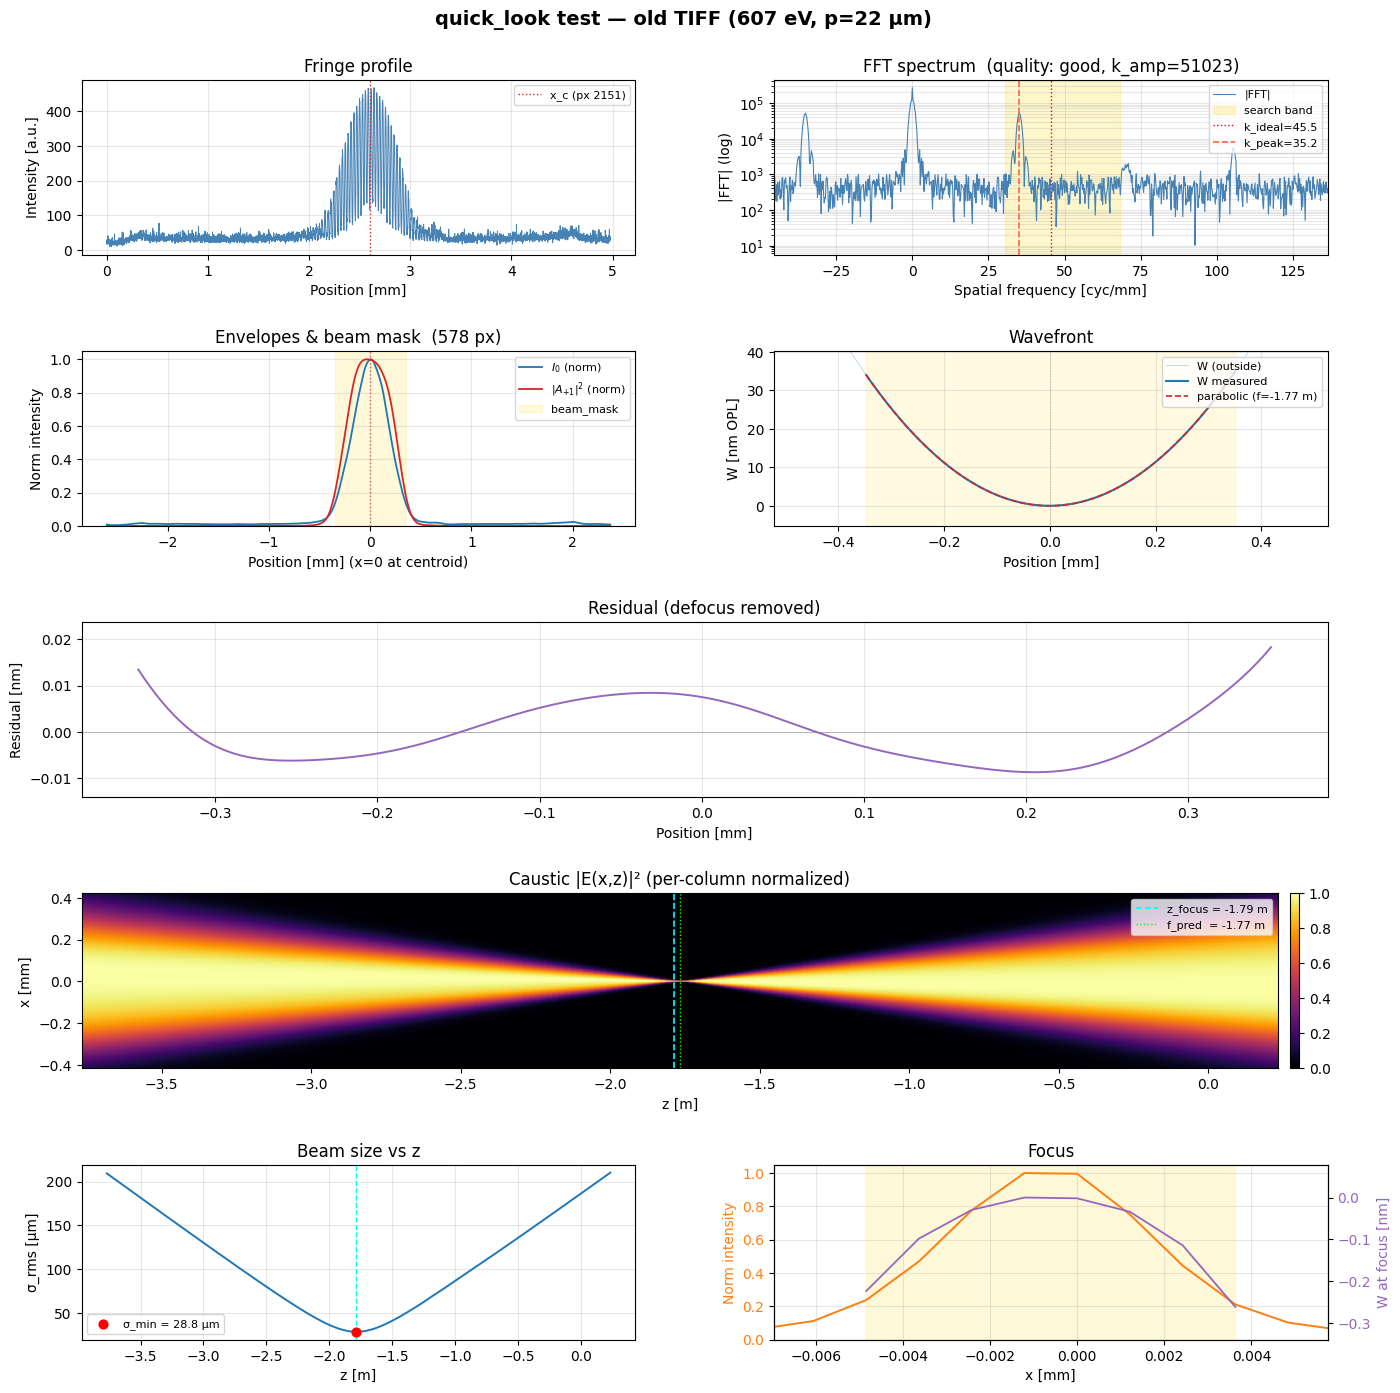

Quick check: result is dict with 49 keys
f_pred via result_ql: -1.768 m


In [50]:
# quick_look — single call from image to plot+numbers
result_ql = quick_look(
    im_arr, dx_m, grating_pitch_m, wavelength_m, z_gd_old_m,
    y_roi=y_roi_old, axis=axis_old,
    band_factor=1.5,
    propagate=True,
    title='quick_look test — old TIFF (607 eV, p=22 µm)',
)

# Confirm it returns the result dict
print(f"Quick check: result is dict with {len(result_ql)} keys")
print(f"f_pred via result_ql: {result_ql['f_pred']:+.3f} m")


# TEST

In [51]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image

import wfs_live as wfl


Loaded: WFS210515-0002-025.tif
Image dimensions: 4112 × 3008 pixels


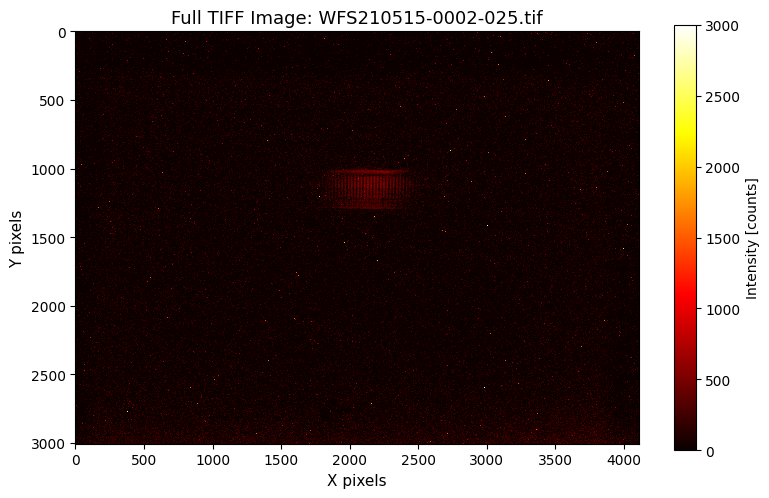

In [52]:
# Load TIFF Image
filename = "WFS210515-0002-025.tif"
im = Image.open(f'{filename}')
width, height = im.size

print(f"Loaded: {filename}")
print(f"Image dimensions: {width} × {height} pixels")

# Visualize full image
plt.figure(figsize=(8, 5))
plt.imshow(np.array(im), cmap='hot', interpolation='nearest', vmax=3000)
plt.title(f'Full TIFF Image: {filename}', fontsize=13)
plt.xlabel('X pixels', fontsize=11)
plt.ylabel('Y pixels', fontsize=11)
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

# Convert to numpy array for the rest of the analysis
im_arr = np.array(im, dtype=float)


In [53]:
# Physical Parameters (Experimental Setup)

camera_pixel_m = 3.45e-6      # Camera pixel size [m]
magnification = 2.85          # Objective magnification (Boli optics)
dx_m = camera_pixel_m / magnification  # Effective pixel size [m]

energy_eV = 607               # Photon energy [eV]
wavelength_m = wfl.energy_eV_to_wavelength_m(energy_eV)

# Grating
grating_pitch_m = 22e-6       # Shearing grating pitch [m]

# Geometry
z_gd_m = 0.4                  # Grating-to-detector distance [m]

# ROI: row band over the beam (fringes along x, beam centered ~y=1100)
y_roi = slice(1090, 1190)
axis  = 0                     # average over rows → profile along columns

print(f"λ = {wavelength_m*1e9:.3f} nm   dx = {dx_m*1e6:.2f} µm")
print(f"p = {grating_pitch_m*1e6:.0f} µm   z_gd = {z_gd_m*1e3:.0f} mm")


λ = 2.043 nm   dx = 1.21 µm
p = 22 µm   z_gd = 400 mm


─── Test A: quick_look (no propagation) ───
[good]  λ=2.04nm  k_peak=35.2 cyc/mm  k_amp=51023  f_pred=-1.77m  RMS_W=10.3nm  RMS_resid=0.006nm


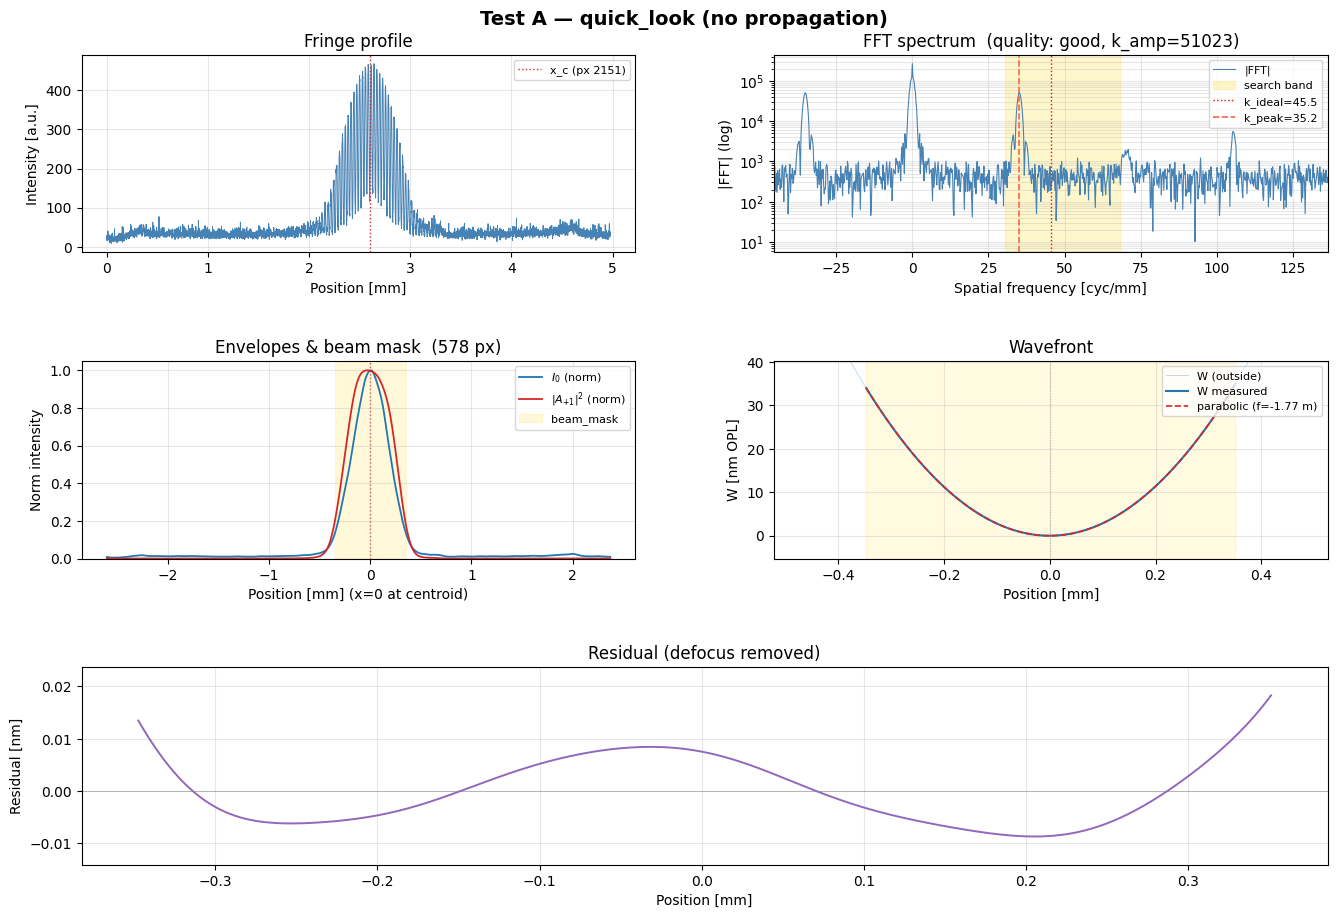


─── Test B: quick_look (with propagation, ~5–10 s) ───
[good]  λ=2.04nm  k_peak=35.2 cyc/mm  k_amp=51023  f_pred=-1.77m  RMS_W=10.3nm  RMS_resid=0.006nm  z_focus=-1.79m  RMS@focus=0.094nm


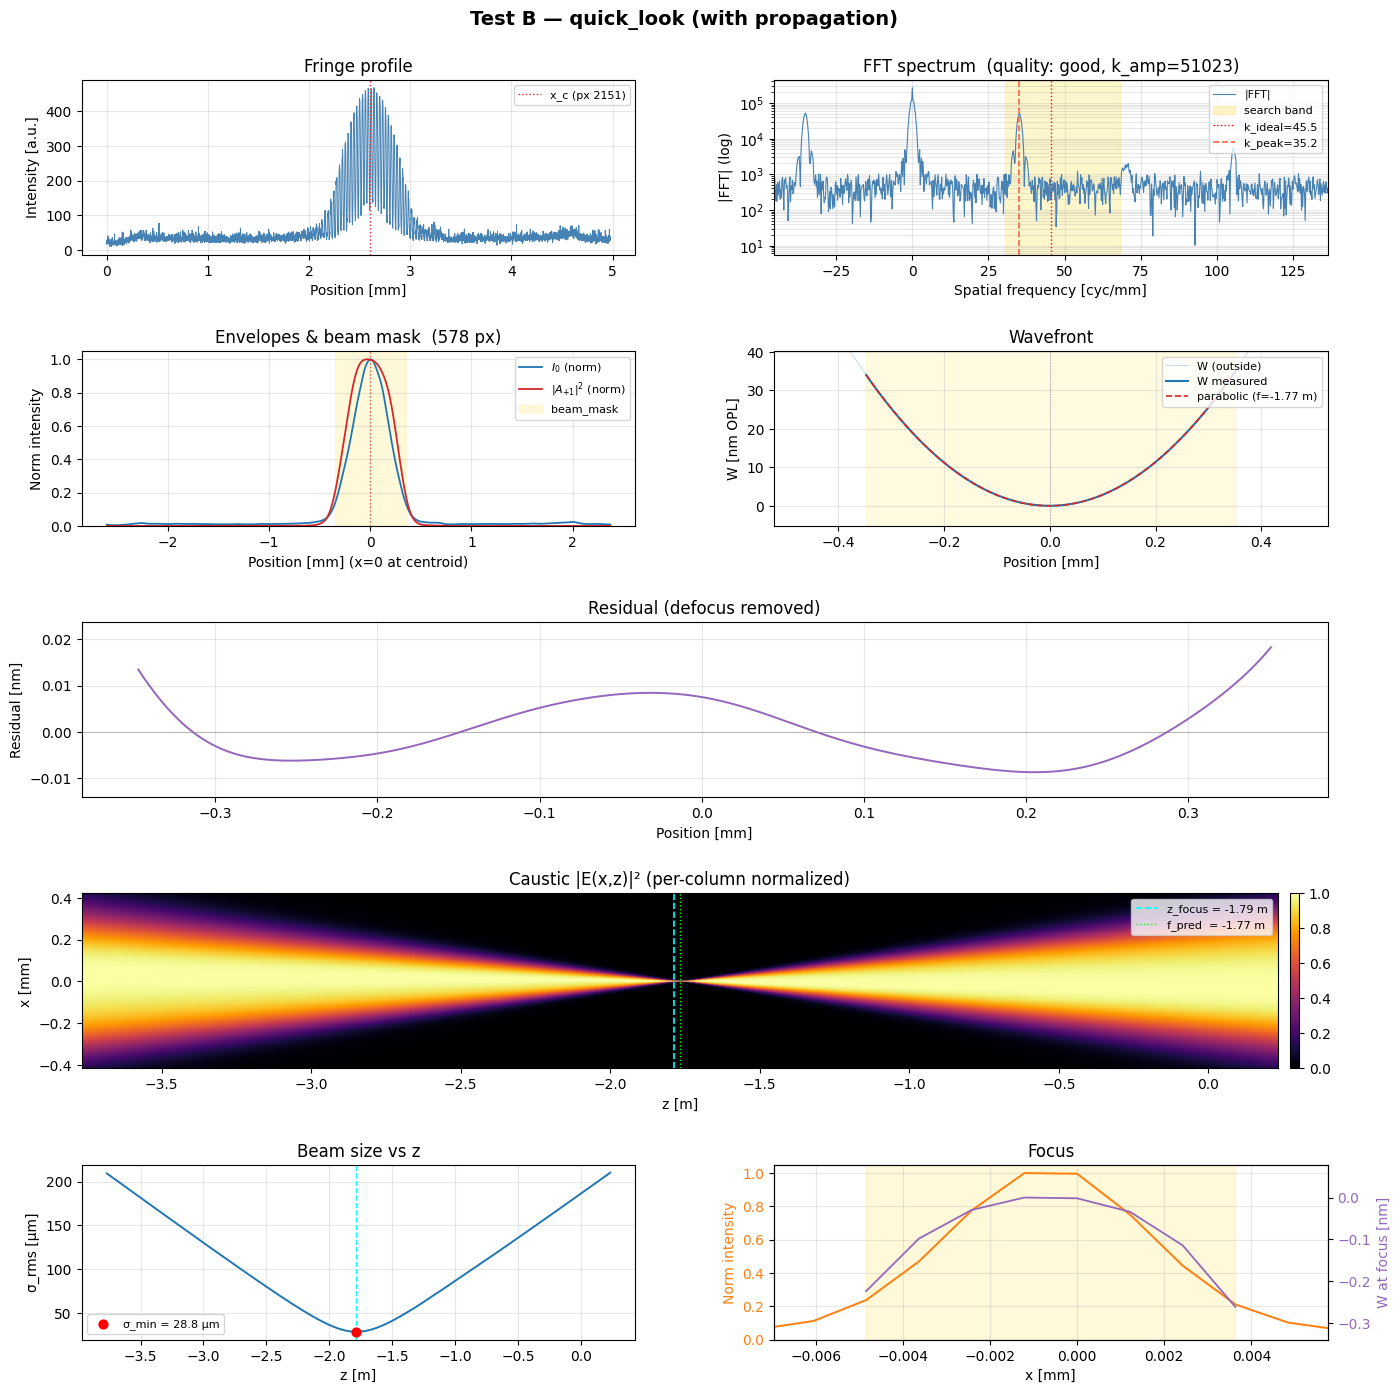


─── Test C: reconstruct_single + plot_result ───
[good]  λ=2.04nm  k_peak=35.2 cyc/mm  k_amp=51023  f_pred=-1.77m  RMS_W=10.3nm  RMS_resid=0.006nm  z_focus=-1.79m  RMS@focus=0.094nm


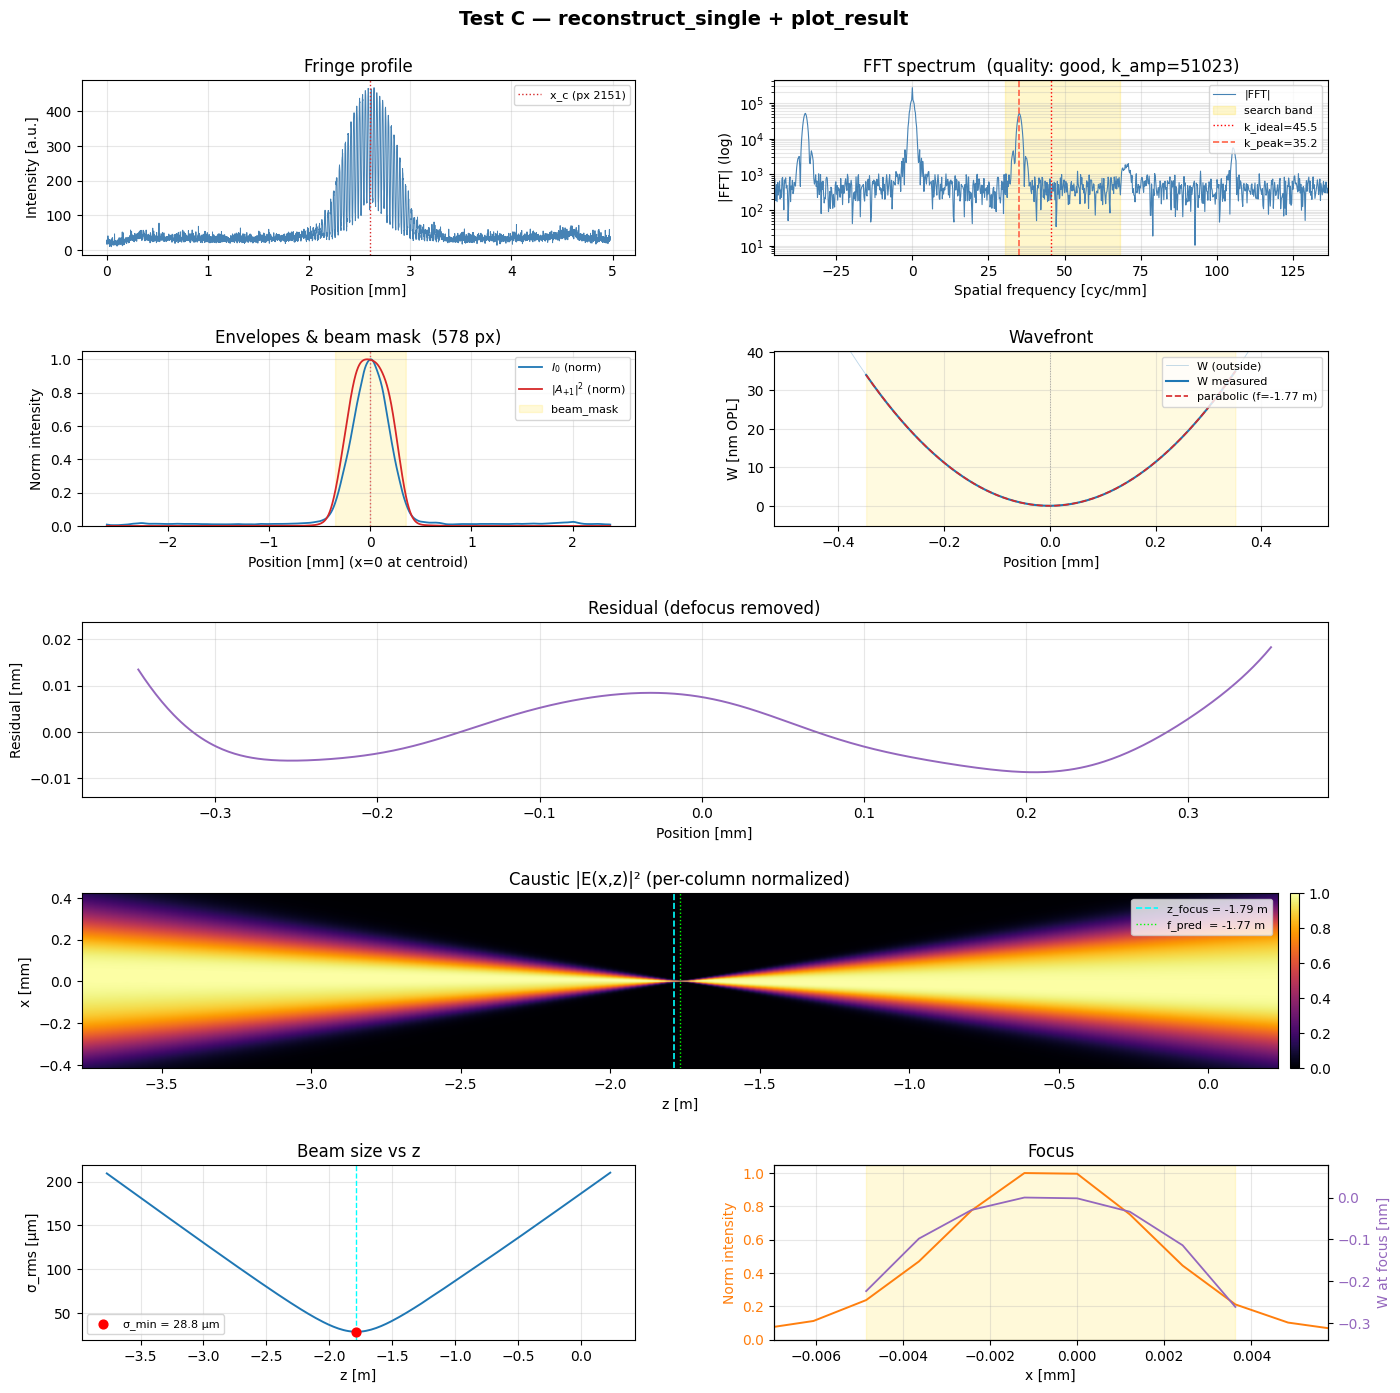


─── Self-consistency check (B vs C) ───
f_pred     B=-1.7677  C=-1.7677  m
z_focus    B=-1.7877  C=-1.7877  m
RMS@focus  B=0.0938  C=0.0938  nm


In [54]:
# Test A: quick_look — one-call image → reconstruction + plot
print("─── Test A: quick_look (no propagation) ───")
r_quick = wfl.quick_look(
    im_arr, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=axis,
    title='Test A — quick_look (no propagation)',
)

# Test B: quick_look with propagation
print("\n─── Test B: quick_look (with propagation, ~5–10 s) ───")
r_quick_prop = wfl.quick_look(
    im_arr, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=axis,
    propagate=True,
    title='Test B — quick_look (with propagation)',
)

# Test C: reconstruct_single + plot_result separately
# Shows the manual two-step workflow that quick_look wraps
print("\n─── Test C: reconstruct_single + plot_result ───")
r_manual = wfl.reconstruct_single(
    im_arr, dx_m, grating_pitch_m, wavelength_m, z_gd_m,
    y_roi=y_roi, axis=axis,
    propagate=True,
    verbose=True,
)
wfl.plot_result(r_manual, title='Test C — reconstruct_single + plot_result')

# Confirm B and C give identical numbers
print("\n─── Self-consistency check (B vs C) ───")
print(f"f_pred     B={r_quick_prop['f_pred']:+.4f}  C={r_manual['f_pred']:+.4f}  m")
print(f"z_focus    B={r_quick_prop['z_focus']:+.4f}  C={r_manual['z_focus']:+.4f}  m")
print(f"RMS@focus  B={r_quick_prop['rms_at_focus_nm']:.4f}  C={r_manual['rms_at_focus_nm']:.4f}  nm")

# NOTES
